# Why are the Guardians always better than expected? An exploration of relief pitcher value by a frustrated fan of a different AL Central team

## Introduction
Every year, many analysts use advanced stats to predict the outcomes of the upcoming season. In particular, baseball has a rich ecosystem of advanced stats, both due to its large sample sizes and the relative ease of assigning specific outcomes to individual players. Over the past few years, my favorite MLB team, the Minnesota Twins, has often been picked to finish first in their division by analytics-based forecasts. Anecdotally, it feels like the Cleveland Guardians, one of the Twins' division rivals, outperfrom their expectations, either making the division race closer than expected or outright beating the Twins. During the 2024 season, the Guardians continued to score and allow runs at rates that suggested they shouldn't keep up their division-leading pace... but they did anyway.

## A brief note on WAR, and why I'm studying relief pitchers
Wins Above Replacement, abbreviated WAR, is an all-encompassing statistic meant to quantify how many wins a player is worth to his team relative to a "replacement player." This replacement level is defined as the average level of a player who would get called up to the major leagues in the event of an injury- for instance, if I were a major league player worth 3.0 WAR over the 2024 season, my team would be expected to win 3 more games with me than they would have if I suddenly retired and decided not to play before the season started. There is no single agreed-upon formula for WAR yet, but the two most prominent public-facing versions of WAR are published by the websites Fangraphs and Baseball Reference. These two sites' WAR totals often differ slightly for specific players, but are usually in the same ballpark as each other (pun intended).

Because it's well-accepted in analytics circles that "clutch" hitting and pitching isn't sustainable over time in baseball, WAR is computed based on individual plays and largely doesn't take game situations into account. If I hit a single against a specific pitcher, it would have the same effect on my WAR if it occurred in a tied game as it would in a blowout. WAR is computed first by computing the number of expected runs a player is worth relative to a replacement player, and this is divided by a factor of approximately 10 (this varies slightly year-to-year for a variety of reasons) to calculate WAR.

After the Guardians won games at a seemingly unsustainable rate last year, I had a realization about the assumptions underlying WAR. The context-neutral computation of WAR works well for hitters who play most of the time. It also works well for starting pitchers, who pitch on a pre-scheduled rotation and ideally pitch the majority of the games they appear in. But the usage of relievers isn't context-neutral. Teams use their best relievers in the situations where a run is most likely to swing the outcome of a game. And while the Guardians were winning at a seemingly unsustainable rate, their star reliever, Emmanuel Clase, was having one of the best seasons a relief pitcher has had in recent memory. Because of Clase's performance, I started to wonder if there is a better way to classify the value of a star reliever to his team.

Baseball Reference does account for this concept to some degree through its leverage index, but I had some concerns that it wasn't sufficiently solving the problem. For a quick ballpark estimate, I looked at the player pages for Clase and for Paul Skenes, a young pitcher who is widely (and rightfully) regarded as one of the best starting pitchers in MLB today. I used ERA+ (a measure of ERA relative to the average pitcher and controlled for different stadium environments, where 100 is average and higher is better) as a rough proxy for pitching talent; Clase has a career ERA+ of 223 and Skenes has a career ERA+ of 222 as of today's date (7/28/25). Clase (12.2) has a slightly higher career WAR than Skenes (11.6) according to Baseball Reference, but Clase has pitched 360 innings in his career while Skenes has pitched 266 innings. While there are other factors impacting WAR, such as defense, this comparison makes me suspect that high-leverage situations that relievers are used in are still undervalued in Baseball Reference's WAR calculation. Skenes is still more valuable to a team on a per-season basis because he pitches much more than Clase (and pitchers' stats decline when facing hitters multiple times a game, a situation relievers rarely face), but I suggest the gap between elite starters and elite relievers on team outcomes is closer than publicly-available stats suggest.

Note (July 28, 2025): I decided to include Clase in this section before today's news of Clase's potential involvement in a 2025 gambling scandal. Data from the partially completed 2025 season is referenced in the Clase-Skenes WAR comparison but not used elsewhere in this notebook.

## Methodology
WAR is closely related to the stat Wins Above Average (WAA); WAA uses an average major leaguer as a baseline instead of a replacement-level player and is also context-neutral like WAR. In fact, the difference between WAR and WAA is simply the number of wins an average player would be worth over replacement; this term varies only based on the amount of playing time a player gets.

Win Probability Added (WPA) represents the effect a player's actions have on his team winning a game, and is very context-dependent. Since the usage of relievers is itself context-dependent, I plan to replace the WAA portion of WAR with a player's WPA to get an adjusted, probability-based WAR for relievers.

Currently, I'm using two sources for data. The Python package pybaseball contains an API to download data from Fangraphs, and this data includes WPA and the Fangraphs version of WAR (known as fWAR), but it does not have WAA. I also downloaded a .csv file directly from Baseball Reference's data repository, and this file contains the Baseball Reference version of WAR (known as bWAR or sometimes rWAR) and WAA, but not WPA. Baseball Reference does compute WPA on players' pages, but this data does not appear to be present in the download.

I first show that there is a non-linear polynomial relationship between WAA and WPA which suggests that WAA (and therefore also WAR) undervalues elite relievers. I also include IP (innings pitched) in the regression; since WAR is a cumulative stat, this helps account for elite pitchers who have low WAR totals in some years due to injuries or the shortened 2020 season.

Next, I calculate a modified version of WAR that substitutes WPA for WAA. In my code, I call this pWAR; the letter p in the abbreviation comes from its association with win probability. I find the differential between a team's pWAR and its bWAR for its relief pitchers in each of its seasons from 2010 to 2024 and calculate a projected winning percentage for each team based on bWAR alone, the adjusted pWAR, and a "regressed" pWAR. I calculated this third version by plugging pitchers' IP and WAA stats into the regression found earlier instead of substituting WAA for WPA.

Finally, I show that the version of team WAR computed with pWAR more accurately reflects a team's actual winning percentage than team WAR computed with bWAR alone.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pybaseball as pyb
import unidecode
import os.path

/Users/andrewford/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [3]:
# These files were downloaded from https://www.baseball-reference.com/data/ - you'll have to do the same and update the paths to replicate the results.
# These files are updated daily, but I'm not using the partially completed 2025 season so files from June are sufficient for now.
pitcher_filename_bref = "/Users/andrewford/Documents/DataSets/BaseballData/war_archive-2025-09-28/war_daily_pitch.txt"
batter_filename_bref = "/Users/andrewford/Documents/DataSets/BaseballData/war_archive-2025-09-28/war_daily_bat.txt"

In [4]:
pitcher_data_bref = pd.read_csv(pitcher_filename_bref)
print(pitcher_data_bref.describe())

                age         mlb_ID       year_ID      stint_ID             G  \
count  56418.000000   56785.000000  56860.000000  56860.000000  56860.000000   
mean      27.755220  282297.503601   1974.323233      1.041769     22.265811   
std        4.417133  234794.880642     39.677934      0.382660     18.546886   
min       15.000000  110003.000000   1871.000000      0.000000      0.000000   
25%       25.000000  116176.000000   1942.000000      1.000000      6.000000   
50%       27.000000  122042.000000   1984.000000      1.000000     19.000000   
75%       30.000000  461325.000000   2009.000000      1.000000     34.000000   
max       58.000000  829272.000000   2025.000000      5.000000    106.000000   

                 GS        IPouts  IPouts_start  IPouts_relief            RA  \
count  56860.000000  56860.000000  50641.000000   50641.000000  56860.000000   
mean       8.505874    227.182606    164.340712      60.780494     38.770823   
std       11.680016    243.157544    23

In [5]:
list(pitcher_data_bref.columns)

['name_common',
 'age',
 'mlb_ID',
 'player_ID',
 'year_ID',
 'team_ID',
 'stint_ID',
 'lg_ID',
 'G',
 'GS',
 'IPouts',
 'IPouts_start',
 'IPouts_relief',
 'RA',
 'xRA',
 'xRA_sprp_adj',
 'xRA_extras_adj',
 'xRA_def_pitcher',
 'PPF',
 'PPF_custom',
 'xRA_final',
 'BIP',
 'BIP_perc',
 'RS_def_total',
 'runs_above_avg',
 'runs_above_avg_adj',
 'runs_above_rep',
 'RpO_replacement',
 'GR_leverage_index_avg',
 'WAR',
 'salary',
 'teamRpG',
 'oppRpG',
 'pyth_exponent',
 'waa_win_perc',
 'WAA',
 'WAA_adj',
 'oppRpG_rep',
 'pyth_exponent_rep',
 'waa_win_perc_rep',
 'WAR_rep',
 'ERA_plus',
 'ER_lg']

In [6]:
start_year = 2010
end_year = 2025
pitcher_data_yrs = pitcher_data_bref[pitcher_data_bref['year_ID'] >= start_year]
pitcher_data_yrs = pitcher_data_yrs[pitcher_data_yrs['year_ID'] <= end_year]

# Accounting for openers
During the past decade, some teams have occasionally used "openers" instead of a traditional starter. When a team employs this strategy, they have a pitcher come in for a short stint, typically 1-2 innings to begin a game. After the opener pitches, a traditional starting pitcher generally replaces them. In stat logs, the opener is treated as the starting pitcher and the traditional starting pitcher who pitches several innings is considered to be a reliever. Since this study focuses on pitchers who take on the traditional role of a reliever and pitch in short stints, I have chosen to define a reliever as any pitcher who averages less than 2 innings pitched per pitching appearance. This may misclassify some players if they pitched in a small number of games or switched between the starting rotation and the bullpen midseason, but seems like the best option for a simple definition.

*Note:* The data sets count games played as a pitcher and games played as a hitter separately, so Shohei Ohtani's appearances as a hitter do not cause him to falsely be labeled as a relief pitcher. Ironically, he recorded 1.2 IP in two pitching appearances in 2020, and is counted as a reliever for that year. I might add a requirement that pitchers had a non-zero amount of relief innings pitched.

In [7]:
# Replaced with average length of outing < 2 innings to account for games with openers
#pitcher_data_relievers = pitcher_data_yrs[pitcher_data_yrs['IPouts_relief'] > pitcher_data_yrs['IPouts_start']]
pitcher_data_relievers_bref = pitcher_data_yrs[pitcher_data_yrs['IPouts']/pitcher_data_yrs['G'] <= 6]
pitcher_data_relievers_bref = pitcher_data_relievers_bref[pitcher_data_relievers_bref['IPouts_relief'] > 0]
pitcher_data_starters_bref = pitcher_data_yrs[pitcher_data_yrs['IPouts']/pitcher_data_yrs['G'] > 6]
print(pitcher_data_relievers_bref.describe())
print(pitcher_data_starters_bref.describe())

               age         mlb_ID      year_ID     stint_ID            G  \
count  8592.000000    8592.000000  8592.000000  8592.000000  8592.000000   
mean     28.600908  555240.965549  2018.197509     1.127910    26.122556   
std       3.638740  100281.102904     4.544453     0.369736    23.140042   
min      19.000000  110683.000000  2010.000000     1.000000     1.000000   
25%      26.000000  476206.000000  2014.000000     1.000000     6.000000   
50%      28.000000  572167.000000  2019.000000     1.000000    19.000000   
75%      31.000000  641729.000000  2022.000000     1.000000    44.000000   
max      44.000000  829272.000000  2025.000000     5.000000    92.000000   

                GS       IPouts  IPouts_start  IPouts_relief           RA  \
count  8592.000000  8592.000000   8592.000000    8592.000000  8592.000000   
mean      0.212523    80.163408      1.637686      78.525722    12.918296   
std       0.992929    69.903418      8.487689      68.559023    10.382279   
min    

In [8]:
# checking that Shohei Ohtani's appearances as a hitter don't affect his games total
# adapted previous query to remove pitchers who recorded 0 outs as relievers from this set
# this output should have no data
pitcher_data_relievers_bref[pitcher_data_relievers_bref['name_common'] == 'Shohei Ohtani']

,name_common,age,mlb_ID,player_ID,year_ID,team_ID,stint_ID,lg_ID,G,GS,...,pyth_exponent,waa_win_perc,WAA,WAA_adj,oppRpG_rep,pyth_exponent_rep,waa_win_perc_rep,WAR_rep,ERA_plus,ER_lg


In [9]:
pitcher_data_relievers_bref.head(10)

,name_common,age,mlb_ID,player_ID,year_ID,team_ID,stint_ID,lg_ID,G,GS,...,pyth_exponent,waa_win_perc,WAA,WAA_adj,oppRpG_rep,pyth_exponent_rep,waa_win_perc_rep,WAR_rep,ERA_plus,ER_lg
43207,David Aardsma,28.0,430911.0,aardsda01,2010,SEA,1,AL,53,0,...,1.862,0.5033,0.1749,-0.0282,4.54436,1.870,0.4899,0.5309,115.168421,21.882
43208,Jeremy Accardo,28.0,435618.0,accarje01,2010,TOR,1,AL,5,0,...,1.897,0.4433,-0.2835,-0.0219,4.58560,1.872,0.4856,0.0714,54.466667,3.268
43209,Alfredo Aceves,27.0,469686.0,aceveal01,2010,NYY,1,AL,10,0,...,1.864,0.5011,0.0110,-0.0278,4.57172,1.872,0.4870,0.1289,147.825000,5.913
43210,Jonathan Albaladejo,27.0,452293.0,albaljo01,2010,NYY,1,AL,10,0,...,1.862,0.5042,0.0420,-0.0409,4.56479,1.871,0.4878,0.1210,111.880000,5.594
43211,Matt Albers,27.0,458006.0,alberma01,2010,BAL,1,AL,62,0,...,1.867,0.4949,-0.3162,-0.1644,4.57385,1.872,0.4868,0.8117,92.076316,34.989
43212,Héctor Ambriz,26.0,459932.0,ambrihe01,2010,CLE,1,AL,34,0,...,1.880,0.4719,-0.9554,0.1392,4.59478,1.873,0.4847,0.5159,70.996667,21.299
43215,Scott Atchison,34.0,425786.0,atchisc01,2010,BOS,1,AL,43,1,...,1.875,0.4812,-0.8084,-0.1387,4.59205,1.873,0.4850,0.6397,97.200000,29.160
43216,Andrew Bailey,26.0,457732.0,bailean01,2010,OAK,1,AL,47,0,...,1.849,0.5272,1.2784,0.3320,4.55534,1.871,0.4887,0.5268,281.150000,22.492
43218,Grant Balfour,32.0,346797.0,balfogr01,2010,TBR,1,AL,57,0,...,1.858,0.5114,0.6498,-0.0674,4.54787,1.870,0.4895,0.5936,172.171429,24.104
43220,Daniel Bard,25.0,453268.0,bardda01,2010,BOS,1,AL,73,0,...,1.851,0.5236,1.7228,0.6038,4.55329,1.871,0.4889,0.8037,226.537500,36.246


In [10]:
# This may take several minutes to run if the data is not saved locally
update_file = False # Set to True to update the file even if a local copy exists, or False to use the local copy if one exists
pitcher_filename_fg = "/Users/andrewford/Documents/DataSets/BaseballData/pitching_data_fg.csv"
if os.path.isfile(pitcher_filename_fg) and not update_file:
    pitching_data_fg = pd.read_csv(pitcher_filename_fg)
else:
    pitching_data_fg = pyb.pitching_stats(start_season=start_year, end_season=end_year, league="all", qual=0)
    pitching_data_fg.to_csv(pitcher_filename_fg, index=False)
print(pitching_data_fg.shape)
pitching_data_fg.head(10)

(11425, 393)


,IDfg,Season,Name,Team,Age,W,L,WAR,ERA,G,...,Pit+ FC,Stf+ FS,Loc+ FS,Pit+ FS,Stuff+,Location+,Pitching+,Stf+ FO,Loc+ FO,Pit+ FO
0,10954,2018,Jacob deGrom,NYM,30,10,9,9.0,1.70,32,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1303,2011,Roy Halladay,PHI,34,19,6,8.7,2.35,32,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2036,2015,Clayton Kershaw,LAD,27,16,7,8.6,2.13,33,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2036,2014,Clayton Kershaw,LAD,26,21,3,7.9,1.77,27,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10603,2017,Chris Sale,BOS,28,17,8,7.6,2.90,32,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,13125,2019,Gerrit Cole,HOU,28,20,5,7.5,2.50,33,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,3137,2018,Max Scherzer,WSN,33,18,7,7.5,2.53,33,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,19361,2021,Corbin Burnes,MIL,26,11,5,7.5,2.43,28,...,140.0,NaN,NaN,NaN,132.0,99.0,128.0,NaN,NaN,NaN
8,2036,2011,Clayton Kershaw,LAD,23,21,5,7.3,2.28,33,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1636,2010,Cliff Lee,- - -,31,12,9,7.3,3.18,28,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
list(pitching_data_fg.columns)

['IDfg',
 'Season',
 'Name',
 'Team',
 'Age',
 'W',
 'L',
 'WAR',
 'ERA',
 'G',
 'GS',
 'CG',
 'ShO',
 'SV',
 'BS',
 'IP',
 'TBF',
 'H',
 'R',
 'ER',
 'HR',
 'BB',
 'IBB',
 'HBP',
 'WP',
 'BK',
 'SO',
 'GB',
 'FB',
 'LD',
 'IFFB',
 'Balls',
 'Strikes',
 'Pitches',
 'RS',
 'IFH',
 'BU',
 'BUH',
 'K/9',
 'BB/9',
 'K/BB',
 'H/9',
 'HR/9',
 'AVG',
 'WHIP',
 'BABIP',
 'LOB%',
 'FIP',
 'GB/FB',
 'LD%',
 'GB%',
 'FB%',
 'IFFB%',
 'HR/FB',
 'IFH%',
 'BUH%',
 'Starting',
 'Start-IP',
 'Relieving',
 'Relief-IP',
 'RAR',
 'Dollars',
 'tERA',
 'xFIP',
 'WPA',
 '-WPA',
 '+WPA',
 'RE24',
 'REW',
 'pLI',
 'inLI',
 'gmLI',
 'exLI',
 'Pulls',
 'WPA/LI',
 'Clutch',
 'FB% 2',
 'FBv',
 'SL%',
 'SLv',
 'CT%',
 'CTv',
 'CB%',
 'CBv',
 'CH%',
 'CHv',
 'SF%',
 'SFv',
 'KN%',
 'KNv',
 'XX%',
 'PO%',
 'wFB',
 'wSL',
 'wCT',
 'wCB',
 'wCH',
 'wSF',
 'wKN',
 'wFB/C',
 'wSL/C',
 'wCT/C',
 'wCB/C',
 'wCH/C',
 'wSF/C',
 'wKN/C',
 'O-Swing%',
 'Z-Swing%',
 'Swing%',
 'O-Contact%',
 'Z-Contact%',
 'Contact%',
 'Zone%'

In [12]:
column_list = ['IDfg','Season','Name','Team','IP','Starting','Start-IP','Relieving','Relief-IP','WPA','+WPA','-WPA','RE24','REW','WPA/LI','WAR','G','GS']
pitching_data_wins_fg = pitching_data_fg[column_list]
pitching_data_wins_fg.head(10)

,IDfg,Season,Name,Team,IP,Starting,Start-IP,Relieving,Relief-IP,WPA,+WPA,-WPA,RE24,REW,WPA/LI,WAR,G,GS
0,10954,2018,Jacob deGrom,NYM,217.0,75.8,217.0,NaN,NaN,5.85,18.48,-12.63,52.57,5.70,4.62,9.0,32,32
1,1303,2011,Roy Halladay,PHI,233.2,71.7,233.2,NaN,NaN,4.41,19.04,-14.63,44.83,4.88,3.82,8.7,32,32
2,2036,2015,Clayton Kershaw,LAD,232.2,70.8,232.2,NaN,NaN,4.98,16.30,-11.32,46.05,5.21,5.67,8.6,33,33
3,2036,2014,Clayton Kershaw,LAD,198.1,62.5,198.1,NaN,NaN,5.04,14.74,-9.69,43.95,4.92,4.97,7.9,27,27
4,10603,2017,Chris Sale,BOS,214.1,68.9,214.1,NaN,NaN,3.73,16.09,-12.36,38.99,3.83,4.09,7.6,32,32
5,13125,2019,Gerrit Cole,HOU,212.1,70.1,212.1,NaN,NaN,4.31,14.72,-10.41,49.91,4.94,5.13,7.5,33,33
6,3137,2018,Max Scherzer,WSN,220.2,65.0,220.2,NaN,NaN,4.84,15.70,-10.86,42.84,4.42,4.74,7.5,33,33
7,19361,2021,Corbin Burnes,MIL,167.0,65.3,167.0,NaN,NaN,3.31,12.49,-9.18,34.93,3.55,4.44,7.5,28,28
8,2036,2011,Clayton Kershaw,LAD,233.1,62.2,233.1,NaN,NaN,3.57,16.96,-13.39,35.49,4.16,4.21,7.3,33,33
9,1636,2010,Cliff Lee,- - -,212.1,63.2,211.4,NaN,NaN,2.17,14.94,-12.78,21.67,2.19,3.31,7.3,28,28


In [13]:
pitcher_data_relievers_fg = pitching_data_wins_fg[pitching_data_wins_fg["IP"]/pitching_data_wins_fg["G"] <= 2.0]
pitcher_data_relievers_fg = pitcher_data_relievers_fg[pitcher_data_relievers_fg["Relief-IP"] > 0]
pitcher_data_starters_fg = pitching_data_wins_fg[pitching_data_wins_fg["IP"]/pitching_data_wins_fg["G"] > 2.0]
#relief_pitching_data.head(10)
pitcher_data_relievers_fg[pitcher_data_relievers_fg["Name"] == 'Jhoan Duran']
# Note when combining names, the Fangraphs data doesn't have accents in names


,IDfg,Season,Name,Team,IP,Starting,Start-IP,Relieving,Relief-IP,WPA,+WPA,-WPA,RE24,REW,WPA/LI,WAR,G,GS
1644,21029,2022,Jhoan Duran,MIN,67.2,NaN,NaN,14.3,67.2,4.56,8.90,-4.34,20.08,2.19,1.59,1.5,57,0
2016,21029,2024,Jhoan Duran,MIN,54.1,NaN,NaN,11.5,54.1,1.53,8.82,-7.29,-1.21,-0.12,0.13,1.2,58,0
2235,21029,2023,Jhoan Duran,MIN,62.1,NaN,NaN,10.7,62.1,2.01,10.47,-8.46,14.15,1.42,1.26,1.1,59,0


In [14]:
try:
    del pitcher_data_bref
    print("pitcher_data_bref deleted successfully")
except NameError:
    print("pitcher_data_bref was not defined, cannot delete")
except Exception as e:
    print(f"An error occurred while deleting pitcher_data_bref: {e}")
try:
    del pitcher_data_yrs
    print("pitcher_data_yrs deleted successfully")
except NameError:
    print("pitcher_data_yrs was not defined, cannot delete")
except Exception as e:
    print(f"An error occurred while deleting pitcher_data_yrs: {e}")
try:
    del pitching_data_fg
    print("pitching_data_fg deleted successfully")
except NameError:
    print("pitching_data_fg was not defined, cannot delete")
except Exception as e:
    print(f"An error occurred while deleting pitching_data_fg: {e}")
try:
    del relief_pitching_data
    print("relief_pitching_data deleted successfully")
except NameError:
    print("relief_pitching_data was not defined, cannot delete")
except Exception as e:
    print(f"An error occurred while deleting relief_pitching_data: {e}")
try:
    del pitching_data_wins_fg
    print("pitching_data_wins_fg deleted successfully")
except NameError:
    print("pitching_data_wins_fg was not defined, cannot delete")
except Exception as e:
    print(f"An error occurred while deleting pitching_data_wins_fg: {e}")


pitcher_data_bref deleted successfully
pitcher_data_yrs deleted successfully
pitching_data_fg deleted successfully
relief_pitching_data was not defined, cannot delete
pitching_data_wins_fg deleted successfully


In [15]:
# Added an ascii version of the name to match the name field from the Fangraphs data
pitcher_data_relievers_bref['name_ascii'] = pitcher_data_relievers_bref['name_common'].apply(unidecode.unidecode)
pitcher_data_starters_bref['name_ascii'] = pitcher_data_starters_bref['name_common'].apply(unidecode.unidecode)
pitcher_data_relievers_bref[pitcher_data_relievers_bref['name_common'] == 'Jhoan Durán']

,name_common,age,mlb_ID,player_ID,year_ID,team_ID,stint_ID,lg_ID,G,GS,...,waa_win_perc,WAA,WAA_adj,oppRpG_rep,pyth_exponent_rep,waa_win_perc_rep,WAR_rep,ERA_plus,ER_lg,name_ascii


In [16]:
pitcher_data_relievers_bref.sort_values(by=['name_common', 'year_ID'],ascending = False)
pitcher_data_relievers_fg.sort_values(by=['Name', 'Season'], ascending = False)
pitcher_data_starters_bref.sort_values(by=['name_common', 'year_ID'], ascending = False)
pitcher_data_starters_fg.sort_values(by=['Name', 'Season'], ascending = False)
print(pitcher_data_relievers_bref.head())
print(pitcher_data_relievers_fg.head())

               name_common   age    mlb_ID  player_ID  year_ID team_ID  \
43207        David Aardsma  28.0  430911.0  aardsda01     2010     SEA   
43208       Jeremy Accardo  28.0  435618.0  accarje01     2010     TOR   
43209       Alfredo Aceves  27.0  469686.0  aceveal01     2010     NYY   
43210  Jonathan Albaladejo  27.0  452293.0  albaljo01     2010     NYY   
43211          Matt Albers  27.0  458006.0  alberma01     2010     BAL   

       stint_ID lg_ID   G  GS  ...  waa_win_perc     WAA  WAA_adj  oppRpG_rep  \
43207         1    AL  53   0  ...        0.5033  0.1749  -0.0282     4.54436   
43208         1    AL   5   0  ...        0.4433 -0.2835  -0.0219     4.58560   
43209         1    AL  10   0  ...        0.5011  0.0110  -0.0278     4.57172   
43210         1    AL  10   0  ...        0.5042  0.0420  -0.0409     4.56479   
43211         1    AL  62   0  ...        0.4949 -0.3162  -0.1644     4.57385   

       pyth_exponent_rep  waa_win_perc_rep  WAR_rep    ERA_plus   ER

In [17]:
print(pitcher_data_relievers_fg['Team'].unique())

['OAK' 'SEA' 'LAD' 'SDP' 'BOS' 'CIN' 'KCR' 'ATL' 'NYY' 'NYM' '- - -' 'TOR'
 'MIA' 'BAL' 'MIL' 'CHW' 'CLE' 'CHC' 'STL' 'MIN' 'TEX' 'TBR' 'PIT' 'SFG'
 'HOU' 'PHI' 'LAA' 'COL' 'ARI' 'WSN' 'DET' 'FLA']


In [18]:
combined_pitching_data_relievers = pd.merge(pitcher_data_relievers_bref, pitcher_data_relievers_fg, left_on=['name_ascii', 'year_ID'], right_on=['Name', 'Season'], how='inner')
combined_pitching_data_starters = pd.merge(pitcher_data_starters_bref, pitcher_data_starters_fg, left_on=['name_ascii', 'year_ID'], right_on=['Name', 'Season'], how='inner')
# this is a temporary workaround for fitting the model- removes players who played for multiple teams because WPA is combined for the whole season for them and bWAR isn't
combined_pitching_data_relievers_single_team = pd.merge(pitcher_data_relievers_bref, pitcher_data_relievers_fg[pitcher_data_relievers_fg['Team'] != '- - -'], left_on=['name_ascii', 'year_ID'], right_on=['Name', 'Season'], how='inner')
combined_pitching_data_starters_single_team = pd.merge(pitcher_data_starters_bref, pitcher_data_starters_fg[pitcher_data_starters_fg['Team'] != '- - -'], left_on=['name_ascii', 'year_ID'], right_on=['Name', 'Season'], how='inner')
combined_columns = ['name_common', 'year_ID', 'WAR_x', 'WAA', 'WAA_adj', 'Name', 'Season', 'WAR_y', 'WPA', '+WPA', '-WPA','IPouts', 'IP']
#print(combined_pitching_data_relievers[combined_columns].head())
print(combined_pitching_data_relievers_single_team[combined_columns].head())
print(combined_pitching_data_starters_single_team[combined_columns].head())


           name_common  year_ID  WAR_x     WAA  WAA_adj                 Name  \
0        David Aardsma     2010   0.68  0.1749  -0.0282        David Aardsma   
1       Jeremy Accardo     2010  -0.23 -0.2835  -0.0219       Jeremy Accardo   
2       Alfredo Aceves     2010   0.11  0.0110  -0.0278       Alfredo Aceves   
3  Jonathan Albaladejo     2010   0.12  0.0420  -0.0409  Jonathan Albaladejo   
4          Matt Albers     2010   0.33 -0.3162  -0.1644          Matt Albers   

   Season  WAR_y   WPA  +WPA  -WPA  IPouts    IP  
0    2010    0.3  0.23  8.10 -7.87     149  49.2  
1    2010    0.1 -0.43  0.51 -0.94      20   6.2  
2    2010    0.0  0.46  0.87 -0.41      36  12.0  
3    2010   -0.1 -0.03  0.17 -0.21      34  11.1  
4    2010    0.0  0.33  4.20 -3.87     227  75.2  
       name_common  year_ID  WAR_x     WAA  WAA_adj             Name  Season  \
0   Brett Anderson     2010   1.92  0.8303  -0.0650   Brett Anderson    2010   
1     Jake Arrieta     2010   0.76 -0.2196  -0.0515  

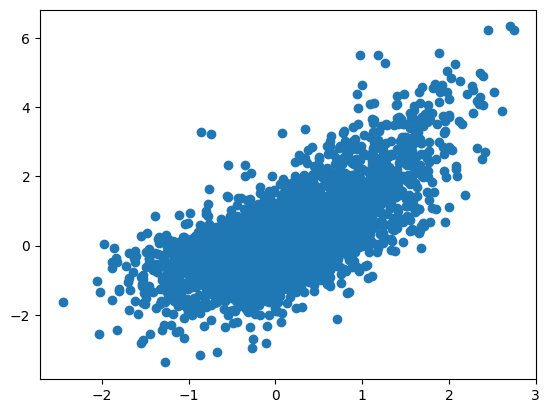

In [19]:
plt.scatter(combined_pitching_data_relievers_single_team['WAA'], combined_pitching_data_relievers_single_team['WPA'])
plt.show()

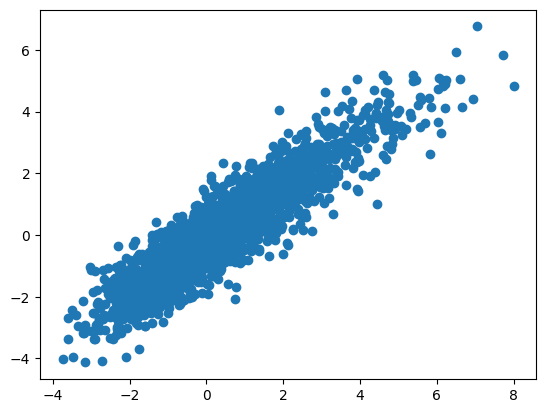

In [20]:
plt.scatter(combined_pitching_data_starters_single_team['WAA'], combined_pitching_data_starters_single_team['WPA'])
plt.show()

In [21]:
# renaming columns to clarify which type of WAR is represented
combined_pitching_data_relievers = combined_pitching_data_relievers.rename(columns={'WAR_x': 'bWAR', 'WAR_y': 'fWAR'})
combined_pitching_data_relievers_single_team = combined_pitching_data_relievers_single_team.rename(columns={'WAR_x': 'bWAR', 'WAR_y': 'fWAR'})
combined_pitching_data_starters = combined_pitching_data_starters.rename(columns={'WAR_x': 'bWAR', 'WAR_y': 'fWAR'})
combined_pitching_data_starters_single_team = combined_pitching_data_starters_single_team.rename(columns={'WAR_x': 'bWAR', 'WAR_y': 'fWAR'})

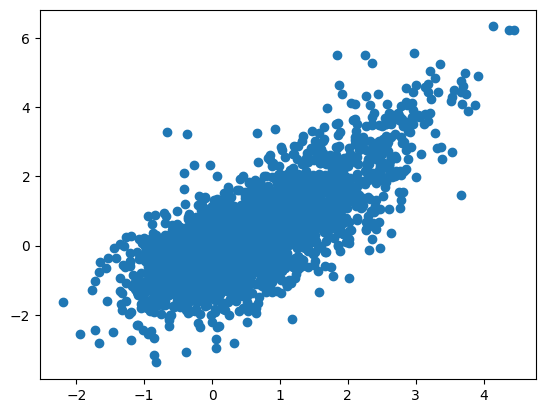

In [22]:
plt.scatter(combined_pitching_data_relievers_single_team['bWAR'], combined_pitching_data_relievers_single_team['WPA'])
plt.show()

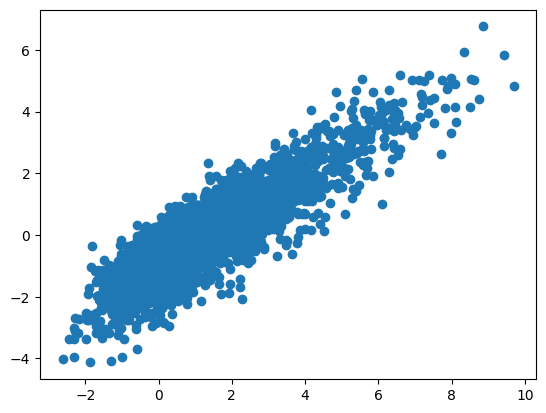

In [23]:
plt.scatter(combined_pitching_data_starters_single_team['bWAR'], combined_pitching_data_starters_single_team['WPA'])

In [24]:
print(f"Full reliever dataset shape: {combined_pitching_data_relievers.shape}")
print(f"Single team reliever dataset shape: {combined_pitching_data_relievers_single_team.shape}")
print(f"Full starter dataset shape: {combined_pitching_data_starters.shape}")
print(f"Single team starter dataset shape: {combined_pitching_data_starters_single_team.shape}")

Full reliever dataset shape: (7758, 62)
Single team reliever dataset shape: (6217, 62)
Full starter dataset shape: (4508, 62)
Single team starter dataset shape: (3955, 62)


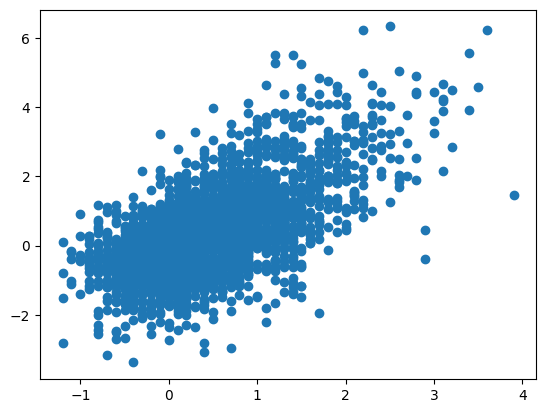

In [25]:
plt.scatter(combined_pitching_data_relievers_single_team['fWAR'], combined_pitching_data_relievers_single_team['WPA'])
plt.show()

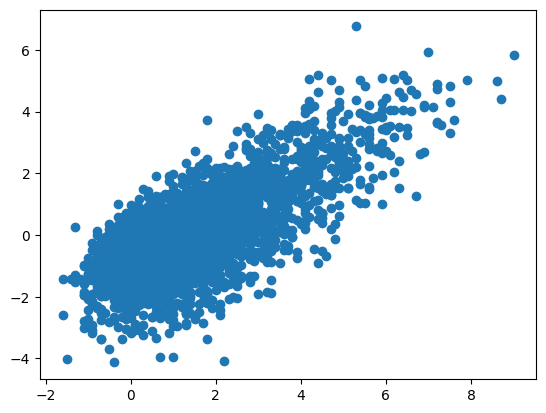

In [26]:
plt.scatter(combined_pitching_data_starters_single_team['fWAR'], combined_pitching_data_starters_single_team['WPA'])
plt.show()

In [27]:
combined_pitching_data_relievers.sort_values(by=['WPA'], ascending=False, inplace=True)
combined_pitching_data_starters.sort_values(by=['WPA'], ascending=False, inplace=True)

In [28]:
combined_pitching_data_relievers.head(10)

,name_common,age,mlb_ID,player_ID,year_ID,team_ID,stint_ID,lg_ID,G_x,GS_x,...,Relief-IP,WPA,+WPA,-WPA,RE24,REW,WPA/LI,fWAR,G_y,GS_y
2615,Zack Britton,28.0,502154.0,brittza01,2016,BAL,1,AL,69,0,...,67.0,6.33,9.96,-3.63,30.89,3.13,2.57,2.5,69,0
7203,Emmanuel Clase,26.0,661403.0,claseem01,2024,CLE,1,AL,74,0,...,74.1,6.23,10.42,-4.19,30.26,3.18,2.97,2.2,74,0
3837,Blake Treinen,30.0,595014.0,treinbl01,2018,OAK,1,AL,68,0,...,80.1,6.22,13.67,-7.45,27.11,2.78,2.57,3.6,68,0
3441,Kenley Jansen,29.0,445276.0,janseke01,2017,LAD,1,NL,65,0,...,68.1,5.57,9.51,-3.94,22.20,2.27,2.45,3.4,65,0
2493,Mark Melancon,30.0,453343.0,melanma01,2015,PIT,1,NL,78,0,...,76.2,5.52,11.64,-6.12,16.44,1.75,1.95,1.4,78,0
4697,Will Smith,29.0,519293.0,smithwi04,2019,SFG,1,NL,63,0,...,65.1,5.50,10.64,-5.14,15.07,1.56,1.62,1.2,63,0
922,Jim Johnson,29.0,462382.0,johnsji04,2012,BAL,1,AL,71,0,...,68.2,5.27,10.94,-5.67,12.49,1.29,2.15,1.2,71,0
659,Tyler Clippard,26.0,461325.0,clippty01,2011,WSN,1,NL,72,0,...,88.1,5.26,10.68,-5.42,28.18,3.06,1.93,1.5,72,0
2732,Andrew Miller,31.0,453192.0,millean01,2016,NYY,1,AL,44,0,...,74.1,5.07,9.91,-4.84,24.82,2.50,2.71,2.9,70,0
2733,Andrew Miller,31.0,453192.0,millean01,2016,CLE,2,AL,26,0,...,74.1,5.07,9.91,-4.84,24.82,2.50,2.71,2.9,70,0


In [29]:
combined_pitching_data_starters.head(10)

,name_common,age,mlb_ID,player_ID,year_ID,team_ID,stint_ID,lg_ID,G_x,GS_x,...,Relief-IP,WPA,+WPA,-WPA,RE24,REW,WPA/LI,fWAR,G_y,GS_y
1578,Zack Greinke,31.0,425844.0,greinza01,2015,LAD,1,NL,32,32,...,NaN,6.76,17.58,-10.82,56.24,6.24,5.47,5.3,32,32
1525,Jake Arrieta,29.0,453562.0,arrieja01,2015,CHC,1,NL,33,33,...,NaN,5.93,15.79,-9.86,56.13,6.04,5.78,7.0,33,33
2480,Jacob deGrom,30.0,594798.0,degroja01,2018,NYM,1,NL,32,32,...,NaN,5.85,18.48,-12.63,52.57,5.70,4.62,9.0,32,32
1266,Johnny Cueto,28.0,456501.0,cuetojo01,2014,CIN,1,NL,34,34,...,NaN,5.20,18.05,-12.85,39.23,4.23,4.50,4.4,34,34
2758,Justin Verlander,36.0,434378.0,verlaju01,2019,HOU,1,AL,34,34,...,NaN,5.19,15.70,-10.51,53.75,5.26,4.82,6.4,34,34
3669,Sandy Alcantara,26.0,645261.0,alcansa01,2022,MIA,1,NL,32,32,...,NaN,5.08,19.50,-14.42,41.47,4.46,4.07,5.9,32,32
1905,Jon Lester,32.0,452657.0,lestejo01,2016,CHC,1,NL,32,32,...,NaN,5.07,15.24,-10.18,42.52,4.33,3.60,4.2,32,32
150,Roy Halladay,33.0,136880.0,hallaro01,2010,PHI,1,NL,33,33,...,NaN,5.05,18.99,-13.94,49.31,5.15,3.40,6.2,33,33
1309,Clayton Kershaw,26.0,477132.0,kershcl01,2014,LAD,1,NL,27,27,...,NaN,5.04,14.74,-9.69,43.95,4.92,4.97,7.9,27,27
381,Jered Weaver,28.0,450308.0,weaveje02,2011,LAA,1,AL,33,33,...,NaN,5.03,17.64,-12.60,46.63,5.07,4.13,5.4,33,33


In [30]:
from sklearn import preprocessing, svm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [31]:
# TODO: Implement a version of this for starters as well, maybe refactor variables
WAA_relievers_shaped = np.array(combined_pitching_data_relievers_single_team['WAA']).reshape(-1,1)
IPouts_relievers_shaped = np.array(combined_pitching_data_relievers_single_team['IPouts']).reshape(-1,1)
X_relievers = np.concatenate((WAA_relievers_shaped, IPouts_relievers_shaped), axis=1)
y_relievers = np.array(combined_pitching_data_relievers_single_team['WPA']).reshape(-1,1)
print(X_relievers.shape, y_relievers.shape)

(6217, 2) (6217, 1)


In [32]:
# Version for starting pitchers - do I need to use IPouts as a variable? Should I keep an eye on the coefficients?
WAA_starters_shaped = np.array(combined_pitching_data_starters_single_team['WAA']).reshape(-1,1)
IPouts_starters_shaped = np.array(combined_pitching_data_starters_single_team['IPouts']).reshape(-1,1)
X_starters = np.concatenate((WAA_starters_shaped, IPouts_starters_shaped), axis=1)
y_starters = np.array(combined_pitching_data_starters_single_team['WPA']).reshape(-1,1)
print(X_starters.shape, y_starters.shape)

(3955, 2) (3955, 1)


August 7 (or really early morning August 8) stopping point

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X_relievers, y_relievers, test_size = 0.2)
regr = LinearRegression()
regr.fit(X_train, y_train)
print("Coefficients: ", regr.coef_)
print("Intercept: ", regr.intercept_)
print(regr.score(X_test, y_test))

Coefficients:  [[1.01056947 0.00141801]]
Intercept:  [0.00294886]
0.5398982197203976


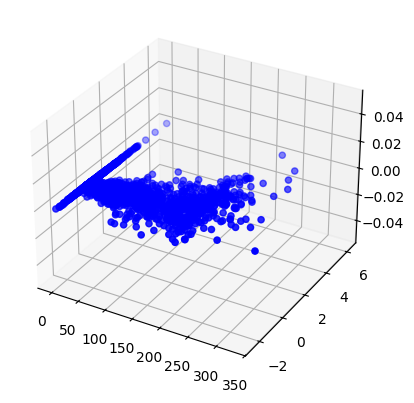

In [34]:
y_pred = regr.predict(X_test)
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(X_test, y_test, color='blue')

It looks like this isn't a perfect linear fit- at the high end, WPA is higher than WAA alone would suggest. I believe this means the effect of leverage is not considered strongly enough to reflect elite relievers' actual effect on performance.

In [35]:
from sklearn.metrics import PredictionErrorDisplay

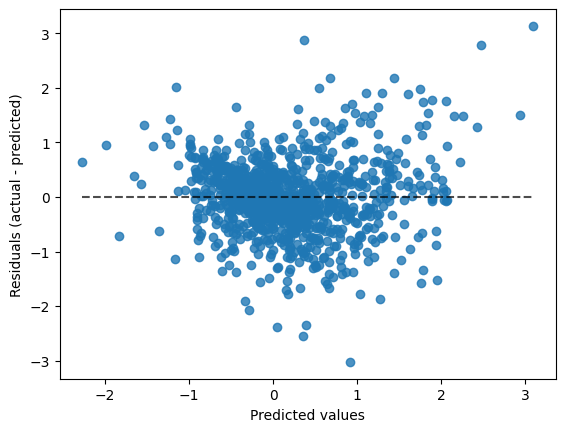

In [36]:
display = PredictionErrorDisplay(y_true=y_test, y_pred=y_pred)
display.plot()
plt.show()

In [37]:
# try a quadratic fit?
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2)
WAA_poly = poly.fit_transform(WAA_relievers_shaped)
#X_poly = poly.fit_transform(X)
X_poly = np.concatenate((WAA_poly, IPouts_relievers_shaped), axis=1)
X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(X_poly, y_relievers, test_size=0.2)
poly_regr = LinearRegression()
poly_regr.fit(X_train_poly, y_train_poly)
print("Coefficients: ", poly_regr.coef_)
print("Intercept: ", poly_regr.intercept_)
print(poly_regr.score(X_test_poly, y_test_poly))

Coefficients:  [[0.00000000e+00 9.40360696e-01 3.12118485e-01 4.07588594e-04]]
Intercept:  [-0.01764825]
0.5509233282579513


In [38]:
X_test_poly_sorted = np.sort(X_test_poly, axis=0)
y_pred_poly = poly_regr.predict(X_test_poly)
y_pred_poly_sorted = poly_regr.predict(X_test_poly_sorted)
#plt.scatter(X_test_poly[:,1], y_test_poly, color='blue')
#plt.plot(X_test_poly_sorted[:,1], y_pred_poly_sorted, color='red', linewidth=3)

In [39]:
print(X_test_poly.shape)
print(y_test_poly.shape)

(1244, 4)
(1244, 1)


In [40]:
print(X_test_poly)

[[ 1.0000000e+00  0.0000000e+00  0.0000000e+00  1.3700000e+02]
 [ 1.0000000e+00 -4.6200000e-01  2.1344400e-01  7.5000000e+01]
 [ 1.0000000e+00 -3.3630000e-01  1.1309769e-01  1.0900000e+02]
 ...
 [ 1.0000000e+00  1.6800000e-01  2.8224000e-02  2.5000000e+01]
 [ 1.0000000e+00  4.5000000e-01  2.0250000e-01  3.1000000e+01]
 [ 1.0000000e+00 -1.3020000e-01  1.6952040e-02  1.2000000e+01]]


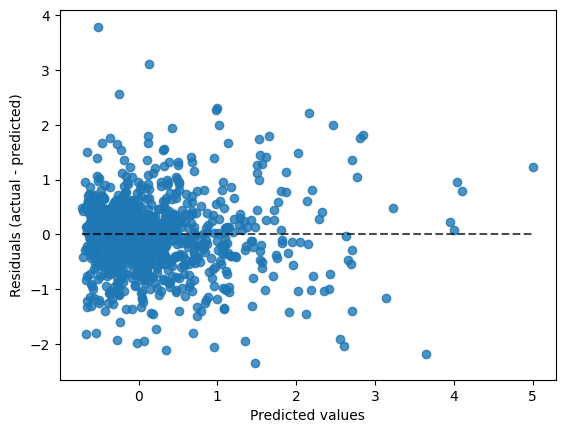

In [41]:
display = PredictionErrorDisplay(y_true=y_test_poly, y_pred=y_pred_poly)
display.plot()
plt.show()

In [42]:
print(combined_pitching_data_relievers_single_team[combined_pitching_data_relievers_single_team['WPA']-combined_pitching_data_relievers_single_team['WAA'] > 3][['name_common','year_ID','team_ID', 'WPA', 'WAA']])

         name_common  year_ID team_ID   WPA     WAA
134   Rafael Soriano     2010     TBR  4.09  1.0880
177       Heath Bell     2010     SDP  4.63  0.9983
561   Tyler Clippard     2011     WSN  5.26  2.0736
789      Jim Johnson     2012     BAL  5.27  1.2638
1127  Ernesto Frieri     2013     LAA  3.24  0.0737
1420    Brad Ziegler     2013     ARI  3.98  0.9516
2107     Seth Maness     2015     STL  3.27 -0.8588
2119   Mark Melancon     2015     PIT  5.52  0.9750
2220    Zack Britton     2016     BAL  6.33  2.7048
2780     Ryan Tepera     2017     TOR  3.37  0.3431
2883   Kenley Jansen     2017     LAD  5.57  1.8850
3175   Blake Treinen     2018     OAK  6.22  2.4480
3842      Will Smith     2019     SFG  5.50  1.1844
4665      Josh Hader     2021     MIL  5.05  1.9740
5599     Alexis Díaz     2023     CIN  4.37  0.9372
5814  Emmanuel Clase     2024     CLE  6.23  2.7454
6098    Tyler Kinley     2024     COL  3.22 -0.7437


Some of the players in the table above seemed to have incredible luck in some years. For instance, in 2024, Tyler Kinley had a pretty bad ERA overall, but wasn't charged with any runs (earned or unearned) in his 17 highest-leverage appearances. This generally isn't repeatable.

In [43]:
# Initialization code to easily switch between models
WAA_shaped = WAA_relievers_shaped
#WAA_shaped = WAA_starters_shaped
IPouts_shaped = IPouts_relievers_shaped
#IPouts_shaped = IPouts_starters_shaped
X = X_relievers
#X = X_starters
y = y_relievers
#y = y_starters

Below code:

Roughly equal fit for relievers for degrees 2-5, degree 1 is consistently worse

For relievers, the quality of the fit is much closer for all degrees. IP and non-linear powers of WAA also have smaller coefficients

Degree 1 - Coefficients:  [[0.00139592 0.         1.00090934]]
Degree 1 - Intercept:  [-0.00159907]
Degree 1 - Score:  0.5253251930631175


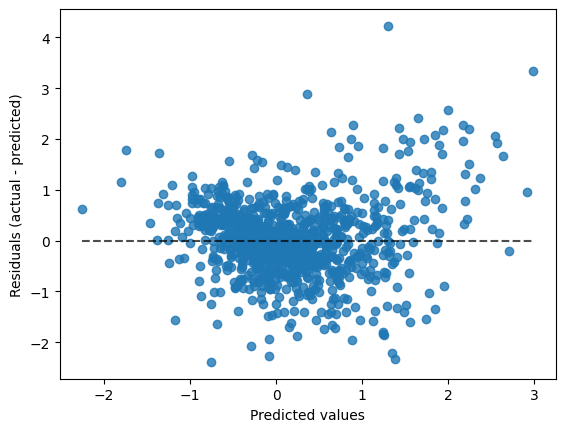

Degree 2 - Coefficients:  [[4.26138514e-04 2.22044605e-16 9.29240117e-01 2.96723317e-01]]
Degree 2 - Intercept:  [-0.02031853]
Degree 2 - Score:  0.5806933628363217


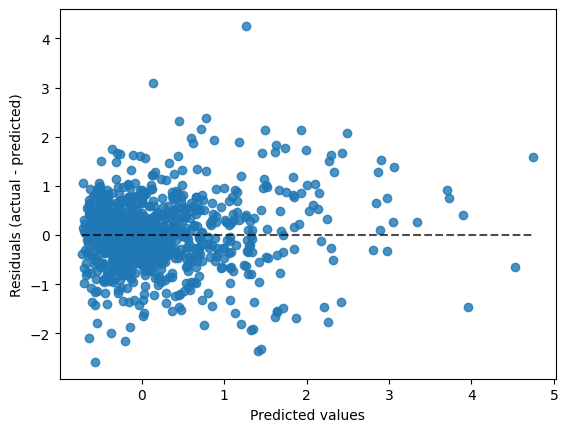

Degree 3 - Coefficients:  [[5.62951709e-04 2.22044605e-16 8.44677774e-01 2.53717184e-01
  5.84401173e-02]]
Degree 3 - Intercept:  [-0.02451588]
Degree 3 - Score:  0.583354731242494


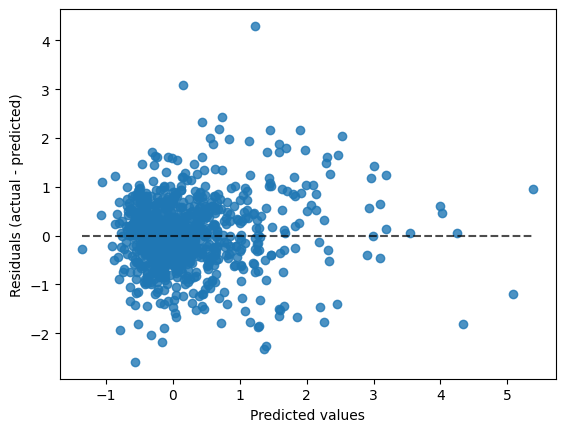

Degree 4 - Coefficients:  [[ 5.05275049e-04 -1.55431223e-15  8.21925100e-01  3.20191588e-01
   8.09896240e-02 -2.51045546e-02]]
Degree 4 - Intercept:  [-0.03139832]
Degree 4 - Score:  0.583962707148249


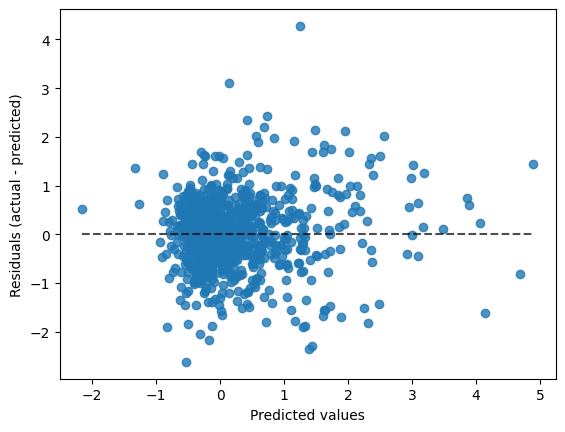

Degree 5 - Coefficients:  [[ 4.77925252e-04  1.66533454e-16  8.47646721e-01  3.53494218e-01
   3.99629912e-02 -3.90263609e-02  1.06885158e-02]]
Degree 5 - Intercept:  [-0.03285882]
Degree 5 - Score:  0.5820577901602173


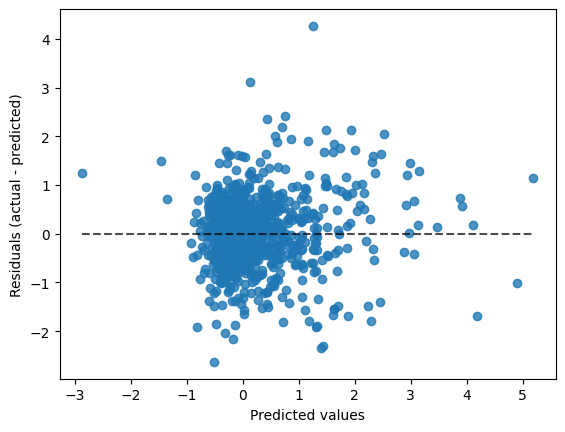

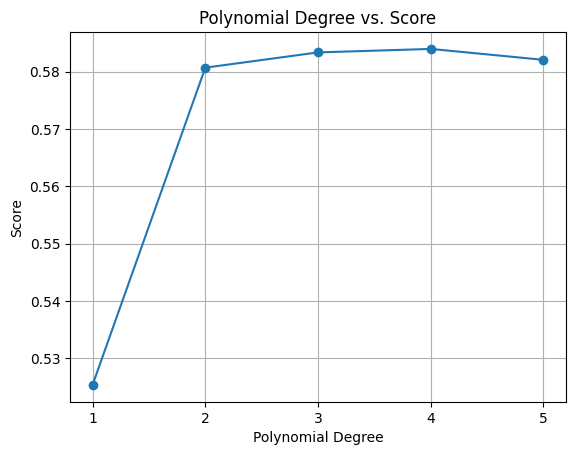

In [44]:
# Making a for loop to try different polynomial degrees
# This regenerates the test set each time, but I've run it several tims and the degree 3 polynomial seems to be the best fit in general
degree_max = 5 # this maximum is probably excessive, I would expect degree 2-3 at most
polynomial_scores = np.zeros([2,degree_max])
# including this to use the same test set for all degrees
poly_full = PolynomialFeatures(degree=degree_max)
WAA_poly_full = poly_full.fit_transform(WAA_shaped)
X_poly_full = np.concatenate((IPouts_shaped, WAA_poly_full), axis=1)
X_train_poly_full, X_test_poly_full, y_train_poly_full, y_test_poly_full = train_test_split(X_poly_full, y, test_size=0.2)
for degree in range(1, degree_max + 1):
    #WAA_poly = WAA_poly_full[:, :degree + 1]  # Use the precomputed polynomial features
    #X_poly = np.concatenate((WAA_poly, IPouts_shaped), axis=1)
    #X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(X_poly, y, test_size=0.2)
    X_train_poly = X_train_poly_full[:, :degree + 2]  # Use the precomputed polynomial features
    X_test_poly = X_test_poly_full[:, :degree + 2]  # Use the precomputed polynomial features
    y_train_poly = y_train_poly_full
    y_test_poly = y_test_poly_full
    poly_regr = LinearRegression()
    poly_regr.fit(X_train_poly, y_train_poly)
    print(f"Degree {degree} - Coefficients: ", poly_regr.coef_)
    if degree == 2:
        quadratic_coefficients = poly_regr.coef_
    print(f"Degree {degree} - Intercept: ", poly_regr.intercept_)
    print(f"Degree {degree} - Score: ", poly_regr.score(X_test_poly, y_test_poly))
    
    score_index = degree - 1
    polynomial_scores[0, score_index] = degree
    polynomial_scores[1, score_index] = poly_regr.score(X_test_poly, y_test_poly)

    X_test_poly_sorted = np.sort(X_test_poly, axis=0)
    y_pred_poly = poly_regr.predict(X_test_poly)
    y_pred_poly_sorted = poly_regr.predict(X_test_poly_sorted)
    
    #plt.scatter(X_test_poly[:,1], y_test_poly, color='blue')
    #plt.plot(X_test_poly_sorted[:,1], y_pred_poly_sorted, color='red', linewidth=3)
    #plt.title(f"Polynomial Degree {degree}")
    #plt.show()
    
    display = PredictionErrorDisplay(y_true=y_test_poly, y_pred=y_pred_poly)
    display.plot()
    plt.show()
# Plotting the polynomial scores
plt.plot(polynomial_scores[0], polynomial_scores[1], marker='o')
plt.title("Polynomial Degree vs. Score")
plt.xlabel("Polynomial Degree")
plt.ylabel("Score")
plt.xticks(np.arange(1, degree_max + 1))
plt.grid()
plt.show()

Do the same thing for starting pitchers and hitters to see if it's linear?

# Translating findings to WAR

I plan to replace WAA with WPA in the WAR calculation for each reliever to get an adjusted WAR. Next, I'll combine these results with the WAR values for starting pitchers and batters for each team. With this data, I'll compare the two versions of WAR to see which correlates better with team records.

# Challenges

I have to check how the data handles pitchers batting- it includes NL data from before the universal DH. I think batting WAR and pitching WAR are computed separately, since they had to consider this with Ohtani. I also have to check to see if players' separate stints with each team are handled differently. Finally, I'm not sure why the two files have different WAR totals for some players- what's going on there? Also, what about pitcher fielding?

# Other notes
From looking at player pages, I determined that WAR_x is bWAR, and WAR_y is fWAR. I might look at different combinations of WAR (BRef, FG, or my adjusted one for relievers) to see what is more consistent with team wins. Among starters, hitters, and relievers, this leads to 12 possible combinations.

In [45]:
combined_pitching_data_relievers.shape

(7758, 62)

In [46]:
combined_pitching_data_relievers[['name_common','year_ID','WAA','bWAR','fWAR','WPA']].head(10)

,name_common,year_ID,WAA,bWAR,fWAR,WPA
2615,Zack Britton,2016,2.7048,4.14,2.5,6.33
7203,Emmanuel Clase,2024,2.7454,4.44,2.2,6.23
3837,Blake Treinen,2018,2.4480,4.37,3.6,6.22
3441,Kenley Jansen,2017,1.8850,2.98,3.4,5.57
2493,Mark Melancon,2015,0.9750,1.84,1.4,5.52
4697,Will Smith,2019,1.1844,2.25,1.2,5.50
922,Jim Johnson,2012,1.2638,2.35,1.2,5.27
659,Tyler Clippard,2011,2.0736,3.36,1.5,5.26
2732,Andrew Miller,2016,1.4696,2.34,2.9,5.07
2733,Andrew Miller,2016,0.9958,1.40,2.9,5.07


# Problem to resolve

It looks like Baseball Reference and Fangraphs handle cases where a player was traded midseason differently from each other. The bWAR data is split into the two stints, while fWAR and WPA represent the full season. Maybe I could resolve this by using fWAR instead of bWAR as the base later on?

Update: Using fWAR instead of bWAR introduces other problems. I might have to look for a split in WPA or another way to handle it (split proportionally? Not perfect because usage could change). I'm not sure there's really a good and accurate way to do this.

In [47]:
# add a column for the adjusted WAR for relievers using bWAR
combined_pitching_data_relievers.insert(combined_pitching_data_relievers.shape[1], 'pWAR', combined_pitching_data_relievers['bWAR'] + combined_pitching_data_relievers['WPA'] - combined_pitching_data_relievers['WAA'])
pwar_regr_idx = combined_pitching_data_relievers.shape[1]
combined_pitching_data_relievers.insert(pwar_regr_idx, 'pWAR_proj', 0.0)
wpa_regr_idx = combined_pitching_data_relievers.shape[1]
combined_pitching_data_relievers.insert(wpa_regr_idx, 'WPA_regr', 0.0)
#combined_pitching_data.insert(combined_pitching_data.shape[1], 'prob_bWAR', combined_pitching_data['bWAR'] + combined_pitching_data['WPA'] - combined_pitching_data['WAA'])
# add a column for the adjusted WAR for relievers using fWAR
# maybe don't do this because WAA is not available for fWAR
#combined_pitching_data.insert(combined_pitching_data.shape[1], 'prob_fWAR', combined_pitching_data['fWAR'] + combined_pitching_data['WPA'] - combined_pitching_data['WAA'])

In [48]:
# Only use if you have to rerun the previous cell for some reason
#combined_pitching_data_relievers.drop(['pWAR', 'pWAR_proj', 'WPA_regr'], inplace=True, axis=1)

In [49]:
# use the regression to convert WAA and IP to a projected WPA and then to a projected WAR
# the AI tool completely hallucinated the formulas wpa = 0.1 * waa + 0.2 * ip_outs + bwar and war = wpa / 10
# when I added quadratic to the function name it just squared waa and ip_outs
def projected_war_quadratic(bwar,waa,ip_outs,coefficients=quadratic_coefficients):
    # Calculate the projected WPA using the regression coefficients
    # format of coefficients: IP_outs first, then WAA from lowest power (0) to highest (n)
    poly_degree = len(coefficients) - 2
    projected_wpa = coefficients[poly_degree + 1]
    # implements the WAA portion of the below commented line for any degree polynomial
    for i in range(poly_degree, 0, -1):
        projected_wpa *= waa
        projected_wpa += coefficients[i]
    # projected_wpa = (coefficients[0] * ip_outs) + ((coefficients[3] * waa) + coefficients[2]) * waa + coefficients[1]
    projected_wpa += coefficients[0] * ip_outs
    #projected_wpa = (0.1 * waa) + (0.2 * ip_outs) + bwar
    # Calculate the projected WAR
    projected_war = bwar + projected_wpa - waa
    #projected_war = projected_wpa / 10
    return projected_war,projected_wpa

In [50]:
n_rows = combined_pitching_data_relievers.shape[0]
for i in range(n_rows):
    bwar = combined_pitching_data_relievers.iloc[i]['bWAR']
    waa = combined_pitching_data_relievers.iloc[i]['WAA']
    ip_outs = combined_pitching_data_relievers.iloc[i]['IPouts']
    projected_war, projected_wpa = projected_war_quadratic(bwar, waa, ip_outs, quadratic_coefficients[0])
    combined_pitching_data_relievers.iat[i, pwar_regr_idx] = projected_war
    combined_pitching_data_relievers.iat[i, wpa_regr_idx] = projected_wpa

In [51]:
print(quadratic_coefficients)
print(combined_pitching_data_relievers[['name_common', 'year_ID', 'bWAR', 'WAA', 'WPA', 'pWAR', 'pWAR_proj', 'WPA_regr']].head(10))

[[4.26138514e-04 2.22044605e-16 9.29240117e-01 2.96723317e-01]]
         name_common  year_ID  bWAR     WAA   WPA    pWAR  pWAR_proj  WPA_regr
2615    Zack Britton     2016  4.14  2.7048  6.33  7.7652   6.205073  4.769873
7203  Emmanuel Clase     2024  4.44  2.7454  6.23  7.9246   6.577234  4.882634
3837   Blake Treinen     2018  4.37  2.4480  6.22  8.1420   6.077654  4.155654
3441   Kenley Jansen     2017  2.98  1.8850  5.57  6.6650   3.988301  2.893301
2493   Mark Melancon     2015  1.84  0.9750  5.52  6.3850   2.151094  1.286094
4697      Will Smith     2019  2.25  1.1844  5.50  6.5656   2.665960  1.600360
922      Jim Johnson     2012  2.35  1.2638  5.27  6.3562   2.822282  1.736082
659   Tyler Clippard     2011  3.36  2.0736  5.26  6.5464   4.602055  3.315655
2732   Andrew Miller     2016  2.34  1.4696  5.07  5.9404   2.934807  2.064407
2733   Andrew Miller     2016  1.40  0.9958  5.07  5.4742   1.660847  1.256647


In [52]:
combined_pitching_data_relievers[['name_common','team_ID','year_ID','G_x','WAA','bWAR','fWAR','pWAR','pWAR_proj','WPA','WPA_regr']].head(10)

,name_common,team_ID,year_ID,G_x,WAA,bWAR,fWAR,pWAR,pWAR_proj,WPA,WPA_regr
2615,Zack Britton,BAL,2016,69,2.7048,4.14,2.5,7.7652,6.205073,6.33,4.769873
7203,Emmanuel Clase,CLE,2024,74,2.7454,4.44,2.2,7.9246,6.577234,6.23,4.882634
3837,Blake Treinen,OAK,2018,68,2.4480,4.37,3.6,8.1420,6.077654,6.22,4.155654
3441,Kenley Jansen,LAD,2017,65,1.8850,2.98,3.4,6.6650,3.988301,5.57,2.893301
2493,Mark Melancon,PIT,2015,78,0.9750,1.84,1.4,6.3850,2.151094,5.52,1.286094
4697,Will Smith,SFG,2019,63,1.1844,2.25,1.2,6.5656,2.665960,5.50,1.600360
922,Jim Johnson,BAL,2012,71,1.2638,2.35,1.2,6.3562,2.822282,5.27,1.736082
659,Tyler Clippard,WSN,2011,72,2.0736,3.36,1.5,6.5464,4.602055,5.26,3.315655
2732,Andrew Miller,NYY,2016,44,1.4696,2.34,2.9,5.9404,2.934807,5.07,2.064407
2733,Andrew Miller,CLE,2016,26,0.9958,1.40,2.9,5.4742,1.660847,5.07,1.256647


In [53]:
combined_pitching_data_relievers.insert(combined_pitching_data_relievers.shape[1], 'WPA_scaled', combined_pitching_data_relievers['WPA'])
# initializes the scaled version as the original pWAR so it doesn't change if a player played for one team

In [54]:
combined_pitching_data_relievers_copy = combined_pitching_data_relievers.copy()

In [55]:
# Loop to scale the pWAR values for players who played for multiple teams in a season
for name in combined_pitching_data_relievers['name_common'].unique():
    for year in combined_pitching_data_relievers['year_ID'].unique():
        player_data = combined_pitching_data_relievers[(combined_pitching_data_relievers['name_common'] == name) & (combined_pitching_data_relievers['year_ID'] == year)]
        if len(player_data) > 1:
            # Scale the pWAR values by the number of games played for each team that year
            total_player_games = sum(player_data['G_x'])
            for team in player_data['team_ID'].unique():
                # Scale the pWAR values for each team
                team_games = player_data.loc[player_data['team_ID'] == team, 'G_x'].values[0]
                team_wpa = player_data.loc[player_data['team_ID'] == team, 'WPA'].values[0]
                combined_pitching_data_relievers.loc[(combined_pitching_data_relievers['name_common'] == name) & (combined_pitching_data_relievers['year_ID'] == year) & (combined_pitching_data_relievers['team_ID'] == team), 'WPA_scaled'] = team_wpa*team_games/total_player_games

In [56]:
combined_pitching_data_relievers.head(10)

,name_common,age,mlb_ID,player_ID,year_ID,team_ID,stint_ID,lg_ID,G_x,GS_x,...,RE24,REW,WPA/LI,fWAR,G_y,GS_y,pWAR,pWAR_proj,WPA_regr,WPA_scaled
2615,Zack Britton,28.0,502154.0,brittza01,2016,BAL,1,AL,69,0,...,30.89,3.13,2.57,2.5,69,0,7.7652,6.205073,4.769873,6.330000
7203,Emmanuel Clase,26.0,661403.0,claseem01,2024,CLE,1,AL,74,0,...,30.26,3.18,2.97,2.2,74,0,7.9246,6.577234,4.882634,6.230000
3837,Blake Treinen,30.0,595014.0,treinbl01,2018,OAK,1,AL,68,0,...,27.11,2.78,2.57,3.6,68,0,8.1420,6.077654,4.155654,6.220000
3441,Kenley Jansen,29.0,445276.0,janseke01,2017,LAD,1,NL,65,0,...,22.20,2.27,2.45,3.4,65,0,6.6650,3.988301,2.893301,5.570000
2493,Mark Melancon,30.0,453343.0,melanma01,2015,PIT,1,NL,78,0,...,16.44,1.75,1.95,1.4,78,0,6.3850,2.151094,1.286094,5.520000
4697,Will Smith,29.0,519293.0,smithwi04,2019,SFG,1,NL,63,0,...,15.07,1.56,1.62,1.2,63,0,6.5656,2.665960,1.600360,5.500000
922,Jim Johnson,29.0,462382.0,johnsji04,2012,BAL,1,AL,71,0,...,12.49,1.29,2.15,1.2,71,0,6.3562,2.822282,1.736082,5.270000
659,Tyler Clippard,26.0,461325.0,clippty01,2011,WSN,1,NL,72,0,...,28.18,3.06,1.93,1.5,72,0,6.5464,4.602055,3.315655,5.260000
2732,Andrew Miller,31.0,453192.0,millean01,2016,NYY,1,AL,44,0,...,24.82,2.50,2.71,2.9,70,0,5.9404,2.934807,2.064407,3.186857
2733,Andrew Miller,31.0,453192.0,millean01,2016,CLE,2,AL,26,0,...,24.82,2.50,2.71,2.9,70,0,5.4742,1.660847,1.256647,1.883143


In [57]:
combined_pitching_data_relievers['pWAR_scaled'] = combined_pitching_data_relievers['bWAR'] + combined_pitching_data_relievers['WPA_scaled'] - combined_pitching_data_relievers['WAA']

In [58]:
relievers_data_cle_2024 = combined_pitching_data_relievers[(combined_pitching_data_relievers['team_ID'] == 'CLE') & (combined_pitching_data_relievers['year_ID'] == 2024)]
print(relievers_data_cle_2024[['name_common','team_ID','year_ID','bWAR','fWAR','pWAR_scaled','pWAR_proj','WPA_regr','WPA_scaled']].head(10))
print(f"Difference in wins in 2024 using WPA: {sum(relievers_data_cle_2024['pWAR_scaled'])-sum(relievers_data_cle_2024['bWAR'])}")
print(f"Difference in wins in 2024 using regression: {sum(relievers_data_cle_2024['pWAR_proj'])-sum(relievers_data_cle_2024['bWAR'])}")

relievers_data_cle_2023 = combined_pitching_data_relievers[(combined_pitching_data_relievers['team_ID'] == 'CLE') & (combined_pitching_data_relievers['year_ID'] == 2023)]
print(relievers_data_cle_2023[['name_common','team_ID','year_ID','bWAR','fWAR','pWAR_scaled','pWAR_proj','WPA_regr','WPA_scaled']].head(10))
print(f"Difference in wins in 2023 using WPA: {sum(relievers_data_cle_2023['pWAR_scaled'])-sum(relievers_data_cle_2023['bWAR'])}")
print(f"Difference in wins in 2023 using regression: {sum(relievers_data_cle_2023['pWAR_proj'])-sum(relievers_data_cle_2023['bWAR'])}")

         name_common team_ID  year_ID  bWAR  fWAR  pWAR_scaled  pWAR_proj  \
7203  Emmanuel Clase     CLE     2024  4.44   2.2     7.924600   6.577234   
7401      Cade Smith     CLE     2024  2.41   2.7     3.680200   3.224717   
7244   Hunter Gaddis     CLE     2024  2.61   1.6     3.260800   3.414082   
7272      Tim Herrin     CLE     2024  1.74   1.0     2.125000   2.176006   
7267     Sam Hentges     CLE     2024  0.37   0.3     0.807500   0.397630   
7162     Pedro Avila     CLE     2024  0.63   0.2     1.022222   0.721693   
7382  Erik Sabrowski     CLE     2024  0.60   0.4     0.350000   0.680558   
7341      Eli Morgan     CLE     2024  1.09   0.3     0.603600   1.279586   
7165    Scott Barlow     CLE     2024  0.19   0.0     0.620500   0.290342   
7383    Nick Sandlin     CLE     2024 -0.06  -0.7     0.619200   0.112246   

      WPA_regr  WPA_scaled  
7203  4.882634    6.230000  
7401  2.494517    2.950000  
7244  2.473282    2.320000  
7272  1.651006    1.600000  
7267  0

In [59]:
relievers_data_min_2024 = combined_pitching_data_relievers[(combined_pitching_data_relievers['team_ID'] == 'MIN') & (combined_pitching_data_relievers['year_ID'] == 2024)]
print(relievers_data_min_2024[['name_common','team_ID','year_ID','bWAR','fWAR','pWAR_scaled','pWAR_proj','WPA_regr','WPA_scaled']])
print(f"Difference in wins in 2024: {sum(relievers_data_min_2024['pWAR_scaled'])-sum(relievers_data_min_2024['bWAR'])}")

relievers_data_min_2023 = combined_pitching_data_relievers[(combined_pitching_data_relievers['team_ID'] == 'MIN') & (combined_pitching_data_relievers['year_ID'] == 2023)]
print(relievers_data_min_2023[['name_common','team_ID','year_ID','bWAR','fWAR','pWAR_scaled','pWAR_proj','WPA_regr','WPA_scaled']])
print(f"Difference in wins in 2023: {sum(relievers_data_min_2023['pWAR_scaled'])-sum(relievers_data_min_2023['bWAR'])}")

          name_common team_ID  year_ID  bWAR  fWAR  pWAR_scaled  pWAR_proj  \
7285      Griffin Jax     MIN     2024  2.78   2.6     3.218800   3.509453   
7226      Jhoan Duran     MIN     2024  0.17   1.2     1.874000   0.260756   
7154     Jorge Alcala     MIN     2024  1.35   0.3     1.577800   1.546867   
7413    Brock Stewart     MIN     2024 -0.08   0.1     0.898000  -0.039709   
7181      Matt Bowman     MIN     2024  0.22  -0.2     0.162000   0.226288   
7177    Scott Blewett     MIN     2024  0.80   0.1     0.486000   0.926740   
7410    Josh Staumont     MIN     2024  0.21   0.2     0.327500   0.239666   
7180   Caleb Boushley     MIN     2024  0.02   0.0     0.059800   0.025836   
7195   Diego Castillo     MIN     2024  0.21   0.0    -0.002600   0.221736   
7196     Willi Castro     MIN     2024  0.05   0.0    -0.020000   0.048205   
7235      Kyle Farmer     MIN     2024 -0.02   0.0     0.079900  -0.004856   
7438     Matt Wallner     MIN     2024  0.05   0.0    -0.022500 

In [60]:
relievers_data_kcr_2024 = combined_pitching_data_relievers[(combined_pitching_data_relievers['team_ID'] == 'KCR') & (combined_pitching_data_relievers['year_ID'] == 2024)]
print(relievers_data_kcr_2024[['name_common','team_ID','year_ID','bWAR','fWAR','pWAR_scaled','pWAR_proj','WPA_regr','WPA_scaled']])
print(f"Difference in wins in 2024: {sum(relievers_data_kcr_2024['pWAR_scaled'])-sum(relievers_data_kcr_2024['bWAR'])}")

relievers_data_kcr_2023 = combined_pitching_data_relievers[(combined_pitching_data_relievers['team_ID'] == 'KCR') & (combined_pitching_data_relievers['year_ID'] == 2023)]
print(relievers_data_kcr_2023[['name_common','team_ID','year_ID','bWAR','fWAR','pWAR_scaled','pWAR_proj','WPA_regr','WPA_scaled']])
print(f"Difference in wins in 2023: {sum(relievers_data_kcr_2023['pWAR_scaled'])-sum(relievers_data_kcr_2023['bWAR'])}")

            name_common team_ID  year_ID  bWAR  fWAR  pWAR_scaled  pWAR_proj  \
7391     John Schreiber     KCR     2024  0.48   1.1     1.885100   0.542709   
7231        Lucas Erceg     KCR     2024  0.79   1.7     0.759761   0.844334   
7186         Kris Bubic     KCR     2024  0.78   0.9     0.689400   0.853307   
7262      Hunter Harvey     KCR     2024 -0.17   0.7     0.004992  -0.144594   
7393        Colin Selby     KCR     2024 -0.06   0.0     0.123600  -0.038618   
7212        Steven Cruz     KCR     2024  0.24   0.1    -0.018500   0.254808   
7314           Sam Long     KCR     2024  0.69   0.2     0.381700   0.755896   
7353  Walter Pennington     KCR     2024  0.03   0.0    -0.004550   0.028699   
7318       Jordan Lyles     KCR     2024  0.17   0.0    -0.081500   0.178179   
7360        Nick Pratto     KCR     2024  0.04   0.0    -0.019400   0.038122   
7313        Nick Loftin     KCR     2024  0.04   0.0    -0.019600   0.038115   
7260    Garrett Hampson     KCR     2024

# This is one data point, but...

The difference between the results for the Royals and Guardians almost perfectly matches their actual separation in the standings, which is notable because their Pythagorean records were nearly identical (Royals 91-71, Guardiants 90-71). Given that WAR is closely tied to runs, it's worth looking into more combinations of teams.

# Additional steps

Use the regression (quadratic or higher-degree polynomial) to improve predictions for future years based on players' projected WAR from season to season. WPA seems to be pretty volatile year-to-year, but the regression can provide a starting point. It can also account for a pitcher's projected usage changing- for example, if a player moves teams and no longer ranks the same in their new bullpen's hierarchy.

# Other ideas

Explore using teammates' skill levels as a model parameter. The idea is that this can affect how often a reliever is used in high-leverage situations.

Lower the innings threshold to be included in the data sets, especially as team WAR is concerned. I'll have to see what it does to the regression results with a lower or higher cutoff.

In [61]:
# The Marlins have two separate abbreviations because of the name change from Florida to Miami but this shouldn't be an issue for the data set
team_abbr_list = combined_pitching_data_relievers['team_ID'].unique()
print(team_abbr_list)

['BAL' 'CLE' 'OAK' 'LAD' 'PIT' 'SFG' 'WSN' 'NYY' 'MIL' 'TBR' 'MIA' 'COL'
 'KCR' 'ATL' 'SDP' 'SEA' 'MIN' 'BOS' 'TEX' 'CIN' 'DET' 'STL' 'ARI' 'CHW'
 'TOR' 'HOU' 'CHC' 'LAA' 'NYM' 'PHI' 'FLA']


In [62]:
year_list = range(start_year, end_year + 1)
war_adjustments = pd.DataFrame(columns=team_abbr_list)
war_adjustments_proj = pd.DataFrame(columns=team_abbr_list)

In [63]:
# adjust to fix syntax to get the new row in
for year in year_list:
    year_data = combined_pitching_data_relievers[combined_pitching_data_relievers['year_ID'] == year]
    team_war_adjustments = {}
    for team in team_abbr_list:
        team_data = year_data[year_data['team_ID'] == team]
        if not team_data.empty:
            team_war_adjustments[team] = sum(team_data['pWAR_scaled']) - sum(team_data['bWAR'])
        else:
            team_war_adjustments[team] = 0
    war_adjustments = pd.concat([war_adjustments, pd.DataFrame(team_war_adjustments, index=[year])], ignore_index=False)
print(war_adjustments)

/var/folders/l9/rl78x5z50p1fdvqxvwl18w8r0000gn/T/ipykernel_71966/2025758537.py:11: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  war_adjustments = pd.concat([war_adjustments, pd.DataFrame(team_war_adjustments, index=[year])], ignore_index=False)


           BAL       CLE       OAK       LAD       PIT       SFG       WSN  \
2010 -0.236400  3.824914  2.317229 -0.036100 -0.657827  0.808527 -0.760592   
2011  0.602813  4.097300  1.706773  1.871600  1.325700  5.855300  2.452900   
2012  5.608724  1.960392  2.280789 -1.319619  3.759169  5.062238  0.186700   
2013  3.037599  3.524967  1.246900  3.515880  6.695330 -2.072600  2.415142   
2014  6.364507  1.925969 -0.296581  1.625900  4.144397  1.174283  2.478900   
2015  3.660142 -0.828200 -2.705301  1.557099  9.711339  1.681358  0.029210   
2016  5.846781  5.330088 -3.234982  2.267118  1.229141  1.755694 -1.826200   
2017  2.377200  3.619880 -2.979657  5.278693 -0.298024 -2.535434  4.250151   
2018 -0.814884  3.158106  6.621913  2.466571  3.811270  4.382168 -1.790422   
2019 -1.404996  4.351325  1.684598  2.374050  0.426557  7.142755 -1.531682   
2020 -3.699858  3.463100  2.667700  1.047400  0.775856 -0.041400  0.811300   
2021  0.063775  1.214208  0.509918  5.190053  3.037479  5.426953

In [64]:
# adjust to fix syntax to get the new row in
for year in year_list:
    year_data = combined_pitching_data_relievers[combined_pitching_data_relievers['year_ID'] == year]
    team_war_adjustments = {}
    for team in team_abbr_list:
        team_data = year_data[year_data['team_ID'] == team]
        if not team_data.empty:
            team_war_adjustments[team] = sum(team_data['pWAR_proj']) - sum(team_data['bWAR'])
        else:
            team_war_adjustments[team] = 0
    war_adjustments_proj = pd.concat([war_adjustments_proj, pd.DataFrame(team_war_adjustments, index=[year])], ignore_index=False)
print(war_adjustments_proj)

/var/folders/l9/rl78x5z50p1fdvqxvwl18w8r0000gn/T/ipykernel_71966/760774131.py:11: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  war_adjustments_proj = pd.concat([war_adjustments_proj, pd.DataFrame(team_war_adjustments, index=[year])], ignore_index=False)


           BAL       CLE       OAK       LAD       PIT       SFG       WSN  \
2010  1.892201  2.085590  1.951800  1.972045  2.696233  2.467544  1.984929   
2011  2.425673  2.934777  1.684351  2.126640  1.521145  1.839408  2.393926   
2012  3.095760  1.760583  2.451742  1.627853  1.135080  2.310695  2.149575   
2013  1.918506  2.186217  1.517359  3.937039  2.075271  1.284144  2.392448   
2014  2.223850  2.046334  2.633260  1.348301  2.628160  1.442688  2.203783   
2015  3.050173  1.761575  2.982883  2.210434  1.724930  1.966469  0.996708   
2016  4.011791  3.021741  1.608295  2.496656  1.486471  1.324764  1.829576   
2017  2.091187  2.473449  2.099817  2.342642  2.447274  2.823221  2.475279   
2018  2.591576  1.562240  3.261691  1.963951  2.833905  2.564754  2.278593   
2019  1.956757  1.228630  3.526257  1.716273  4.245725  1.715975  2.243475   
2020  0.962911  0.419813  0.730245  0.609162  0.994369  0.805824  0.708118   
2021  4.223610  1.981036  1.446496  2.706209  3.719876  2.538331

In [65]:
print(war_adjustments[['FLA','MIA']])
print(war_adjustments_proj[['FLA','MIA']])

           FLA       MIA
2010 -2.228378         0
2011 -4.594900         0
2012  0.000000 -0.259371
2013  0.000000    0.9398
2014  0.000000   -1.3664
2015  0.000000  0.970328
2016  0.000000  1.633231
2017  0.000000  5.703209
2018  0.000000  3.251354
2019  0.000000  0.695798
2020  0.000000  1.769362
2021  0.000000  -0.45568
2022  0.000000 -3.722708
2023  0.000000  2.659928
2024  0.000000 -1.516109
2025  0.000000         0
           FLA       MIA
2010  2.402110         0
2011  1.462153         0
2012  0.000000  1.372353
2013  0.000000   2.37036
2014  0.000000  2.140835
2015  0.000000  1.699736
2016  0.000000  2.576957
2017  0.000000  3.201062
2018  0.000000    3.7871
2019  0.000000  3.329683
2020  0.000000  1.355072
2021  0.000000  3.129164
2022  0.000000  2.457969
2023  0.000000  3.354212
2024  0.000000  3.082445
2025  0.000000         0


## Next steps

# Reconcile data sources

Some of the outlier values seem related to the difference between fWAR and bWAR, and also the difference in sources for WPA and WAA. Fangraphs and Baseball Reference have WAR, WAA, and WPA for all players, but getting this data requires some extra work beyond what I can get by default from the PyBaseball package and the data files from Baseball Reference.

# Perform a similar analysis with other players

It's worth looking into the relationship between WPA and WAA for starting pitchers and for position players. I have been assuming a regression would yield a line similar to y=x; is this actually true?

# Produce expected win totals for each team based on this adjusted WAR

I want to combine the WAR of all players on a team to get an expected win total. In theory, I should be able to do this by computing the WAR for each team. Then I can compute the average among all teams, get a winning percentage from that based on each team's total games played (usually but not always 162), find the average among all teams, and then find a constant I can add to every team's winning percentage to get a projection.

In [66]:
batter_filename_fg = "/Users/andrewford/Documents/DataSets/BaseballData/batting_data_fg_50pa.csv"
if os.path.isfile(batter_filename_fg):
    batter_data_fg = pd.read_csv(batter_filename_fg)
else:
    batter_data_fg = pyb.batting_stats(start_season=start_year, end_season=end_year, qual=50)
    batter_data_fg.to_csv(batter_filename_fg, index=False)

In [67]:
batter_data_fg = batter_data_fg[batter_data_fg['Team'] != "- - -"]
print(batter_data_fg['Team'].unique())
batter_data_fg.head(10)

['NYY' 'KCR' 'BOS' 'LAA' 'SFG' 'WSN' 'ATL' 'LAD' 'TOR' 'DET' 'TEX' 'HOU'
 'PIT' 'BAL' 'CLE' 'NYM' 'MIL' 'TBR' 'CHC' 'STL' 'CIN' 'ARI' 'OAK' 'SDP'
 'MIA' 'PHI' 'MIN' 'SEA' 'CHW' 'COL' 'FLA']


,IDfg,Season,Name,Team,Age,G,AB,PA,H,1B,...,maxEV,HardHit,HardHit%,Events,CStr%,CSW%,xBA,xSLG,xwOBA,L-WAR
0,15640,2024,Aaron Judge,NYY,32,158,559,704,180,85,...,117.5,238,0.609,391,0.146,0.267,NaN,NaN,NaN,11.6
1,15640,2022,Aaron Judge,NYY,30,157,570,696,177,87,...,118.4,246,0.609,404,0.169,0.287,NaN,NaN,NaN,11.4
2,25764,2024,Bobby Witt Jr.,KCR,24,161,636,709,211,123,...,116.9,259,0.481,538,0.138,0.236,NaN,NaN,NaN,10.5
3,13611,2018,Mookie Betts,BOS,25,136,520,614,180,96,...,110.6,217,0.500,434,0.220,0.270,NaN,NaN,NaN,10.4
4,10155,2013,Mike Trout,LAA,21,157,589,716,190,115,...,NaN,0,NaN,0,0.200,0.266,NaN,NaN,NaN,10.1
5,10155,2012,Mike Trout,LAA,20,139,559,639,182,117,...,NaN,0,NaN,0,0.221,0.293,NaN,NaN,NaN,10.1
6,9166,2012,Buster Posey,SFG,25,148,530,610,178,114,...,NaN,0,NaN,0,0.190,0.251,NaN,NaN,NaN,9.8
7,4727,2011,Jacoby Ellsbury,BOS,27,158,660,732,212,129,...,NaN,0,NaN,0,0.194,0.254,NaN,NaN,NaN,9.5
8,10155,2018,Mike Trout,LAA,26,140,471,608,147,80,...,118.0,162,0.460,352,0.201,0.261,NaN,NaN,NaN,9.5
9,11579,2015,Bryce Harper,WSN,22,153,521,654,172,91,...,116.0,188,0.477,394,0.118,0.226,NaN,NaN,NaN,9.3


In [68]:
batter_data_bref = pd.read_csv(batter_filename_bref)

In [69]:
batter_data_bref = batter_data_bref[batter_data_bref['year_ID'] >= start_year]
batter_data_bref = batter_data_bref[batter_data_bref['year_ID'] <= end_year]
batter_data_bref['name_ascii'] = batter_data_bref['name_common'].apply(unidecode.unidecode)

In [70]:
batter_data_bref = batter_data_bref[batter_data_bref['PA'] > 0]  # Filter out players with no plate appearances
batter_data_bref[['name_common', 'year_ID', 'team_ID', 'PA', 'WAR', 'WAA']].head(10)

,name_common,year_ID,team_ID,PA,WAR,WAA
8,David Aardsma,2015,ATL,1.0,-0.01,-0.01
55,Fernando Abad,2010,HOU,1.0,-0.02,-0.02
57,Fernando Abad,2012,HOU,7.0,-0.05,-0.05
62,Fernando Abad,2016,MIN,1.0,-0.01,-0.01
92,Cory Abbott,2021,CHC,3.0,0.03,0.03
221,CJ Abrams,2022,SDP,139.0,0.06,-0.39
222,CJ Abrams,2022,WSN,163.0,0.00,-0.52
223,CJ Abrams,2023,WSN,614.0,3.45,1.47
224,CJ Abrams,2024,WSN,602.0,3.37,1.49
225,CJ Abrams,2025,WSN,635.0,3.38,1.43


In [71]:
batter_data_bref_cols = batter_data_bref.columns
print(batter_data_bref_cols)

Index(['name_common', 'age', 'mlb_ID', 'player_ID', 'year_ID', 'team_ID',
       'stint_ID', 'lg_ID', 'PA', 'G', 'Inn', 'runs_bat', 'runs_br', 'runs_dp',
       'runs_field', 'runs_infield', 'runs_outfield', 'runs_catcher',
       'runs_good_plays', 'runs_defense', 'runs_position', 'runs_position_p',
       'runs_replacement', 'runs_above_rep', 'runs_above_avg',
       'runs_above_avg_off', 'runs_above_avg_def', 'WAA', 'WAA_off', 'WAA_def',
       'WAR', 'WAR_def', 'WAR_off', 'WAR_rep', 'salary', 'pitcher', 'teamRpG',
       'oppRpG', 'oppRpPA_rep', 'oppRpG_rep', 'pyth_exponent',
       'pyth_exponent_rep', 'waa_win_perc', 'waa_win_perc_off',
       'waa_win_perc_def', 'waa_win_perc_rep', 'OPS_plus', 'TOB_lg', 'TB_lg',
       'name_ascii'],
      dtype='object')


In [72]:
combined_batting_data = pd.merge(batter_data_bref, batter_data_fg, left_on=['name_ascii', 'year_ID', 'team_ID'], right_on=['Name', 'Season', 'Team'], how='inner')

In [73]:
# rename columns to clarify which type of WAR is represented
combined_batting_data = combined_batting_data.rename(columns={'WAR_x': 'bWAR', 'WAR_y': 'fWAR'})

# Getting a baseline: WAA vs WPA for hitters
I'm comparing WAA to WPA for hitters; the null hypothesis is that y=x is an appropriate linear regression function here.

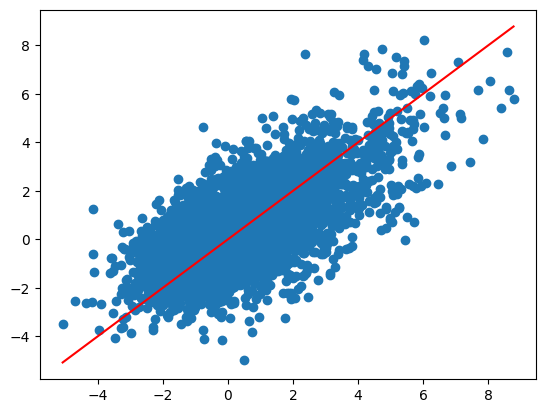

In [74]:
plt.scatter(combined_batting_data['WAA'], combined_batting_data['WPA'])
xmin = combined_batting_data['WAA'].min()
xmax = combined_batting_data['WAA'].max()
plt.plot([xmin, xmax], [xmin, xmax], 'red')
plt.show()

In [75]:
combined_batting_data[['name_common','year_ID','team_ID','WAA','WPA']].head(10)

,name_common,year_ID,team_ID,WAA,WPA
0,CJ Abrams,2023,WSN,1.47,-0.89
1,CJ Abrams,2024,WSN,1.49,1.16
2,Bobby Abreu,2010,LAA,-0.53,2.85
3,Bobby Abreu,2011,LAA,-0.51,3.30
4,Bobby Abreu,2014,NYM,-0.99,0.23
5,José Abreu,2014,CHW,3.61,4.20
6,José Abreu,2015,CHW,1.05,2.18
7,José Abreu,2016,CHW,0.69,0.35
8,José Abreu,2017,CHW,2.48,2.89
9,José Abreu,2018,CHW,0.20,0.80


In [76]:
combined_batting_data[combined_batting_data['WAA'].isna()]

,name_common,age,mlb_ID,player_ID,year_ID,team_ID,stint_ID,lg_ID,PA_x,G_x,...,maxEV,HardHit,HardHit%,Events,CStr%,CSW%,xBA,xSLG,xwOBA,L-WAR


In [77]:
# drops rows with NaN values for WAA and WPA
combined_batting_data = combined_batting_data.dropna(subset=['WAA', 'WPA'])

In [78]:
combined_batting_data[combined_batting_data['WAA'].isna()]

,name_common,age,mlb_ID,player_ID,year_ID,team_ID,stint_ID,lg_ID,PA_x,G_x,...,maxEV,HardHit,HardHit%,Events,CStr%,CSW%,xBA,xSLG,xwOBA,L-WAR


I should have matched on both player name and player team for the hitter data, or on another identifier- the NaN values come from the two Will Smiths in MLB

Coefficients:  [[0.6485169]]
Intercept:  [-0.03573453]
0.46251464968234335


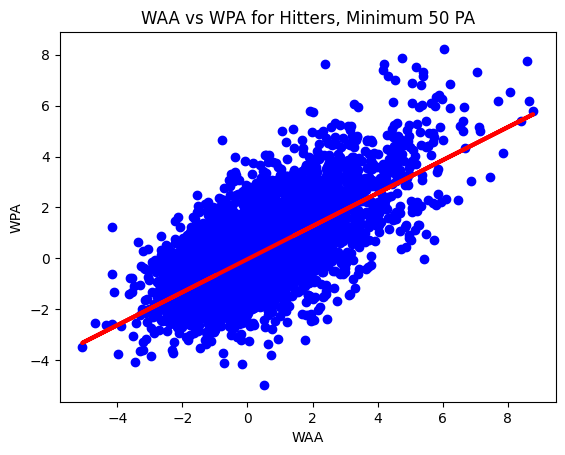

In [79]:
from sklearn.linear_model import LinearRegression
WAA_batter_shaped = np.array(combined_batting_data['WAA']).reshape(-1, 1)
WPA_batter_shaped = np.array(combined_batting_data['WPA']).reshape(-1, 1)
diffs = WPA_batter_shaped - WAA_batter_shaped
regr_batter = LinearRegression()
regr_batter.fit(WAA_batter_shaped, WPA_batter_shaped)
print("Coefficients: ", regr_batter.coef_)
print("Intercept: ", regr_batter.intercept_)
print(regr_batter.score(WAA_batter_shaped, WPA_batter_shaped))
y_pred_batter = regr_batter.predict(WAA_batter_shaped)
plt.scatter(combined_batting_data['WAA'], combined_batting_data['WPA'], color='blue')
plt.plot(combined_batting_data['WAA'], y_pred_batter, color='red', linewidth=3)
plt.xlabel('WAA')
plt.ylabel('WPA')
plt.title('WAA vs WPA for Hitters, Minimum 50 PA')
plt.show()

In [81]:
from scipy import stats

In [82]:
regr_batter = stats.linregress(combined_batting_data['WAA'], diffs.flatten())
print(f"Slope: {regr_batter.slope}, Intercept: {regr_batter.intercept}, R-squared: {regr_batter.rvalue**2}")
print(f"p-value: {regr_batter.pvalue}, Standard Error: {regr_batter.stderr}")

Slope: -0.35148309902811514, Intercept: -0.03573452512836709, R-squared: 0.20176874276338394
p-value: 0.0, Standard Error: 0.008188005086696851


In [83]:
regr_batter_wpa = stats.linregress(combined_batting_data['WPA'], diffs.flatten())
print(f"Slope: {regr_batter_wpa.slope}, Intercept: {regr_batter_wpa.intercept}, R-squared: {regr_batter_wpa.rvalue**2}")
print(f"p-value: {regr_batter_wpa.pvalue}, Standard Error: {regr_batter_wpa.stderr}")

Slope: 0.286811725354873, Intercept: -0.083128758002641, R-squared: 0.12216756068617379
p-value: 1.4522190279292342e-208, Standard Error: 0.009004528967272073


In [84]:
regr_batter_inverse = stats.linregress(combined_batting_data['WPA'], combined_batting_data['WAA'])
print(f"Slope: {regr_batter_inverse.slope}, Intercept: {regr_batter_inverse.intercept}, R-squared: {regr_batter_inverse.rvalue**2}")
print(f"p-value: {regr_batter_inverse.pvalue}, Standard Error: {regr_batter_inverse.stderr}")

Slope: 0.7131882746451271, Intercept: 0.08312875800264101, R-squared: 0.46251464968234324
p-value: 0.0, Standard Error: 0.009004528967272074


In [85]:
regr_batter = stats.linregress(combined_batting_data['WAA'], combined_batting_data['WPA'])
print(f"Slope: {regr_batter.slope}, Intercept: {regr_batter.intercept}, R-squared: {regr_batter.rvalue**2}")
print(f"p-value: {regr_batter.pvalue}, Standard Error: {regr_batter.stderr}")

Slope: 0.6485169009718849, Intercept: -0.03573452512836712, R-squared: 0.46251464968234324
p-value: 0.0, Standard Error: 0.008188005086696851


# Comparing average WPA to WAA for qualified hitters
If a hitter has enough plate appearances in a season to qualify for the batting title, that implies they're good enough to start regularly for their team. Since the average regular starter is better than the average player, it makes sense that the average WPA and the average WAA among this subset of hitters are both positive. Note that they're close together, and there is symmetry between the regressions found when WAA is the independent variable and when WPA is the dependent variable. This is a relationship that does not appear in the WPA/WAA data for relievers.

I did change the threshold for players to appear in the set, bringing average WPA and WAA closer to zero.

In [86]:
print(f"Average WPA: {combined_batting_data['WPA'].mean()}")
print(f"Average WAA: {combined_batting_data['WAA'].mean()}")

Average WPA: 0.03381651124520021
Average WAA: 0.10724629731212289


In [87]:
team_batting_war_bref = pd.DataFrame(columns=team_abbr_list)

In [88]:
for year in year_list:
    year_data = batter_data_bref[batter_data_bref['year_ID'] == year]
    year_team_war = {}
    for team in team_abbr_list:
        team_data = year_data[year_data['team_ID'] == team]
        team_data = team_data.dropna(subset=['WAR'])  # Ensure WAR is not null
        team_batting_war = sum(team_data['WAR'])
        year_team_war[team] = team_batting_war
    team_batting_war_bref = pd.concat([team_batting_war_bref, pd.DataFrame(year_team_war, index=[year])], ignore_index=False)
print(team_batting_war_bref)

/var/folders/l9/rl78x5z50p1fdvqxvwl18w8r0000gn/T/ipykernel_71966/1302587008.py:9: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  team_batting_war_bref = pd.concat([team_batting_war_bref, pd.DataFrame(year_team_war, index=[year])], ignore_index=False)


        BAL    CLE    OAK    LAD    PIT    SFG    WSN    NYY    MIL    TBR  \
2010  11.96  18.05  25.60   9.65  -0.77  22.24  12.42  35.23  26.63  36.15   
2011  17.38  17.91  10.28  18.51   9.12  16.49  15.15  30.14  24.99  33.84   
2012  15.40  17.55  24.20  13.80  15.23  30.00  22.01  29.73  23.46  21.48   
2013  24.93  27.02  23.43  29.49  24.54  23.19  17.87  12.65  17.23  26.94   
2014  29.71  15.30  27.07  33.25  27.92  20.97  23.09  16.34  14.01  18.47   
2015  19.55  15.95  19.63  26.30  21.99  26.21  16.87  20.63  12.36  21.82   
2016  22.44  22.23   8.16  22.00  15.93  25.45  19.68  14.33  13.75  20.67   
2017  20.11  27.57  19.34  28.27  10.48   3.02  21.33  29.41  17.06  21.49   
2018   8.41  27.34  30.17  34.98  17.77   7.98  19.00  33.95  30.67  30.03   
2019  11.66  22.04  32.54  35.04  11.83   7.88  28.36  34.98  18.93  26.04   
2020   6.89   5.25   7.29  15.28  -0.13  11.09   5.54  11.77   1.16  13.50   
2021   9.82  16.18  23.14  23.82   7.05  28.72  27.37  13.66  20

In [89]:
del batter_data_bref

In [90]:
pitcher_data_bref = pd.read_csv(pitcher_filename_bref)
pitcher_data_bref = pitcher_data_bref[pitcher_data_bref['year_ID'] >= start_year]
pitcher_data_bref = pitcher_data_bref[pitcher_data_bref['year_ID'] <= end_year]

In [91]:
team_pitching_war_bref = pd.DataFrame(columns=team_abbr_list)

In [92]:
for year in year_list:
    year_data = pitcher_data_bref[pitcher_data_bref['year_ID'] == year]
    year_team_war = {}
    for team in team_abbr_list:
        team_data = year_data[year_data['team_ID'] == team]
        team_data = team_data.dropna(subset=['WAR'])  # Ensure WAR is not null
        team_pitching_war = sum(team_data['WAR'])
        year_team_war[team] = team_pitching_war
    team_pitching_war_bref = pd.concat([team_pitching_war_bref, pd.DataFrame(year_team_war, index=[year])], ignore_index=False)
print(team_pitching_war_bref)

/var/folders/l9/rl78x5z50p1fdvqxvwl18w8r0000gn/T/ipykernel_71966/337383748.py:9: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  team_pitching_war_bref = pd.concat([team_pitching_war_bref, pd.DataFrame(year_team_war, index=[year])], ignore_index=False)


        BAL    CLE    OAK    LAD    PIT    SFG    WSN    NYY    MIL    TBR  \
2010  12.18   8.79  15.74  17.97   3.74  21.08   7.26  14.94  -0.13  12.82   
2011   4.47  12.23  20.35  15.93  10.82  14.44  12.37  23.52  14.79  16.72   
2012  22.65   2.58  23.54  22.31  10.86   7.72  23.79  21.18   6.16  24.05   
2013  10.48  11.70  21.17  18.18  15.57   4.10  13.61  15.55   5.29  13.07   
2014  16.40  24.26  18.59  15.64  10.31  11.95  24.53  13.69  14.30  17.84   
2015  14.18  21.80   8.83  18.07  19.08  14.30  19.49  20.48   7.98  16.01   
2016  17.63  20.73  15.96  17.28  11.67  17.03  25.06  18.10  13.01  11.01   
2017   6.79  31.48   7.90  19.79  12.90  14.00  26.03  23.16  18.28  11.42   
2018   4.63  23.53  18.45  15.98  12.82  13.73  19.40  16.34   7.91  15.20   
2019   4.79  19.14  21.23  15.81   3.83  12.47  19.37  15.07  14.55  19.78   
2020   8.94   9.43   8.72   9.01  -1.65   2.01   8.50   5.05   6.59   8.03   
2021  -0.17  14.56  16.58  31.85   5.25  26.50  -1.39  27.82  20

In [93]:
total_war_bref = team_batting_war_bref + team_pitching_war_bref
total_war_bref_wpa = total_war_bref + war_adjustments
total_war_bref_wpa_proj = total_war_bref + war_adjustments_proj

In [94]:
total_war_bref

,BAL,CLE,OAK,LAD,PIT,SFG,WSN,NYY,MIL,TBR,...,STL,ARI,CHW,TOR,HOU,CHC,LAA,NYM,PHI,FLA
2010,24.14,26.84,41.34,27.62,2.97,43.32,19.68,50.17,26.50,48.97,...,39.38,17.46,41.57,39.29,16.55,23.04,30.42,30.80,45.09,29.21
2011,21.85,30.14,30.63,34.44,19.94,30.93,27.52,53.66,39.78,50.56,...,36.92,34.08,32.05,34.95,13.57,21.51,41.96,26.75,54.11,26.27
2012,38.05,20.13,47.74,36.11,26.09,37.72,45.80,50.91,29.62,45.53,...,40.87,33.28,42.38,28.26,10.74,16.64,45.60,23.48,30.03,0.00
2013,35.41,38.72,44.60,47.67,40.11,27.29,31.48,28.20,22.52,40.01,...,43.59,29.87,23.85,32.65,8.81,25.84,34.52,23.34,18.06,0.00
2014,46.11,39.56,45.66,48.89,38.23,32.92,47.62,30.03,28.31,36.31,...,34.60,16.42,27.14,40.00,23.26,25.52,46.97,29.94,25.45,0.00
2015,33.73,37.75,28.46,44.37,41.07,40.51,36.36,41.11,20.34,37.83,...,50.06,35.69,25.30,47.95,46.70,39.02,32.04,37.86,13.72,0.00
2016,40.07,42.96,24.12,39.28,27.60,42.48,44.74,32.43,26.76,31.68,...,39.48,22.39,35.19,43.46,37.27,55.78,29.87,37.83,12.44,0.00
2017,26.90,59.05,27.24,48.06,23.38,17.02,47.36,52.57,35.34,32.91,...,34.97,46.67,25.26,26.74,53.30,41.55,31.20,21.20,26.58,0.00
2018,13.04,50.87,48.62,50.96,30.59,21.71,38.40,50.29,38.58,45.23,...,32.83,32.29,17.66,23.63,57.69,45.87,36.41,31.94,27.60,0.00
2019,16.45,41.18,53.77,50.85,15.66,20.35,47.73,50.05,33.48,45.82,...,41.55,34.57,23.49,24.95,67.84,42.55,26.65,38.87,28.18,0.00


In [95]:
sched_min_2023 = pyb.schedule_and_record(2023, 'MIN')
print(sched_min_2023.columns)
print(sched_min_2023.iat[161, 8])
sched_min_2023

http://www.baseball-reference.com/teams/MIN/2023-schedule-scores.shtml
Index(['Date', 'Tm', 'Home_Away', 'Opp', 'W/L', 'R', 'RA', 'Inn', 'W-L',
       'Rank', 'GB', 'Win', 'Loss', 'Save', 'Time', 'D/N', 'Attendance', 'cLI',
       'Streak', 'Orig. Scheduled'],
      dtype='object')
87-75


/Users/andrewford/Library/Python/3.9/lib/python/site-packages/pybaseball/team_results.py:75: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Attendance'].replace(r'^Unknown$', np.nan, regex=True, inplace = True) # make this a NaN so the column can benumeric


,Date,Tm,Home_Away,Opp,W/L,R,RA,Inn,W-L,Rank,GB,Win,Loss,Save,Time,D/N,Attendance,cLI,Streak,Orig. Scheduled
1,"Thursday, Mar 30",MIN,@,KCR,W,2.0,0.0,9.0,1-0,1.0,Tied,López,Greinke,Duran,2:32,D,38351.0,1.01,1,None
2,"Saturday, Apr 1",MIN,@,KCR,W,2.0,0.0,9.0,2-0,1.0,up 0.5,Gray,Lyles,López,2:18,D,16633.0,1.06,2,None
3,"Sunday, Apr 2",MIN,@,KCR,W,7.0,4.0,9.0,3-0,1.0,up 0.5,Ryan,Keller,None,2:35,D,14589.0,1.07,3,None
4,"Monday, Apr 3",MIN,@,MIA,W,11.0,1.0,9.0,4-0,1.0,up 0.5,Mahle,Cueto,None,2:31,N,8898.0,.99,4,None
5,"Tuesday, Apr 4",MIN,@,MIA,L,0.0,1.0,9.0,4-1,1.0,up 0.5,Alcantara,Maeda,None,1:57,N,10668.0,1.07,-1,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
158,"Wednesday, Sep 27",MIN,Home,OAK,W,6.0,4.0,9.0,85-73,1.0,up10.0,Keuchel,Jiménez,Jax,3:00,N,20520.0,.10,3,None
159,"Thursday, Sep 28",MIN,Home,OAK,L,1.0,2.0,9.0,85-74,1.0,up 9.0,Erceg,Maeda,May,2:43,D,19466.0,.07,-1,None
160,"Friday, Sep 29",MIN,@,COL,W,7.0,6.0,9.0,86-74,1.0,up10.0,Funderburk,Kinley,Pagán,2:58,N,47272.0,.01,1,None
161,"Saturday, Sep 30",MIN,@,COL,W,14.0,6.0,9.0,87-74,1.0,up10.0,Paddack,Kauffmann,None,2:57,N,40264.0,.00,2,None


In [96]:
try:
    fail_test = pyb.schedule_and_record(2024,'FLA')
except Exception as e:
    fail_test = {}
fail_test

http://www.baseball-reference.com/teams/FLA/2024-schedule-scores.shtml


{}

In [97]:
teams = pyb.team_ids(2010)
print(teams)

      yearID lgID teamID franchID  teamIDfg teamIDBR teamIDretro
2575    2010   AL    BAL      BAL         2      BAL         BAL
2576    2010   AL    BOS      BOS         3      BOS         BOS
2577    2010   AL    CHA      CHW         4      CHW         CHA
2578    2010   AL    CLE      CLE         5      CLE         CLE
2579    2010   AL    DET      DET         6      DET         DET
2580    2010   AL    KCA      KCR         7      KCR         KCA
2581    2010   AL    LAA      ANA         1      LAA         ANA
2582    2010   AL    MIN      MIN         8      MIN         MIN
2583    2010   AL    NYA      NYY         9      NYY         NYA
2584    2010   AL    OAK      OAK        10      OAK         OAK
2585    2010   AL    SEA      SEA        11      SEA         SEA
2586    2010   AL    TBA      TBD        12      TBR         TBA
2587    2010   AL    TEX      TEX        13      TEX         TEX
2588    2010   AL    TOR      TOR        14      TOR         TOR
2589    2010   NL    ARI 

In [98]:
# Importing a key for team abbreviations to match the team names in the standings data
# Incorporates all team name changes from 2010 to present
team_abbr_key_filename = '/Users/andrewford/Documents/DataSets/BaseballData/team_abbreviation_key.csv'
team_abbr_key = pd.read_csv(team_abbr_key_filename)
print(team_abbr_key.shape)
print(team_abbr_key.head())

(34, 2)
             team_name team_abbr
0    Baltimore Orioles       BAL
1       Boston Red Sox       BOS
2    Chicago White Sox       CHW
3    Cleveland Indians       CLE
4  Cleveland Guardians       CLE


In [99]:
team_records = pd.DataFrame(columns=['team_ID', 'year_ID', 'G', 'W', 'L', 'Win_Pct'])
for year in year_list: # Temporary in place of year_list to test
    teams_year = pyb.team_ids(year)
    team_abbr_list_year = teams_year['teamIDBR']
    standings_list = pd.merge(pyb.standings(year), team_abbr_key, left_on='team_ID', right_index=False) # hopefully this works
    for team in team_abbr_list_year:
        team_schedule = pyb.schedule_and_record(year, team)
        games_played = team_schedule.shape[0]
        wl_idx = team_schedule.columns.get_loc('W-L')
        win_loss = team_schedule.iat[games_played-1, wl_idx]
        wins, losses = map(int, win_loss.split('-'))
        win_pct = wins / games_played if games_played > 0 else 0
        team_records = pd.concat([team_records, pd.DataFrame({'team_ID': [team], 'year_ID': [year], 'G': [games_played], 'W': [wins], 'L': [losses], 'Win_Pct': [win_pct]})], ignore_index=True)
print(team_records.head())


TypeError: Can only merge Series or DataFrame objects, a <class 'list'> was passed

In [100]:
pyb.standings(2023)

[                  Tm    W   L  W-L%    GB
 1  Baltimore Orioles  101  61  .623    --
 2     Tampa Bay Rays   99  63  .611   2.0
 3  Toronto Blue Jays   89  73  .549  12.0
 4   New York Yankees   82  80  .506  19.0
 5     Boston Red Sox   78  84  .481  23.0,
                     Tm   W    L  W-L%    GB
 1      Minnesota Twins  87   75  .537    --
 2       Detroit Tigers  78   84  .481   9.0
 3  Cleveland Guardians  76   86  .469  11.0
 4    Chicago White Sox  61  101  .377  26.0
 5   Kansas City Royals  56  106  .346  31.0,
                    Tm   W    L  W-L%    GB
 1      Houston Astros  90   72  .556    --
 2       Texas Rangers  90   72  .556    --
 3    Seattle Mariners  88   74  .543   2.0
 4  Los Angeles Angels  73   89  .451  17.0
 5   Oakland Athletics  50  112  .309  40.0,
                       Tm    W   L  W-L%    GB
 1         Atlanta Braves  104  58  .642    --
 2  Philadelphia Phillies   90  72  .556  14.0
 3          Miami Marlins   84  78  .519  20.0
 4          New Y

In [101]:
standings_2010 = pyb.standings(2010)
print(len(standings_2010))
# The standings_2010 variable is a list of DataFrames, one for each division
al_east_2010 = pd.merge(standings_2010[0], team_abbr_key, left_on='Tm', right_on='team_name', how='left')
al_central_2010 = pd.merge(standings_2010[1], team_abbr_key, left_on='Tm', right_on='team_name', how='left')
al_west_2010 = pd.merge(standings_2010[2], team_abbr_key, left_on='Tm', right_on='team_name', how='left')
nl_east_2010 = pd.merge(standings_2010[3], team_abbr_key, left_on='Tm', right_on='team_name', how='left')
nl_central_2010 = pd.merge(standings_2010[4], team_abbr_key, left_on='Tm', right_on='team_name', how='left')
nl_west_2010 = pd.merge(standings_2010[5], team_abbr_key, left_on='Tm', right_on='team_name', how='left')
al_central_2010

6


,Tm,W,L,W-L%,GB,team_name,team_abbr
0,Minnesota Twins,94,68,.580,--,Minnesota Twins,MIN
1,Chicago White Sox,88,74,.543,6.0,Chicago White Sox,CHW
2,Detroit Tigers,81,81,.500,13.0,Detroit Tigers,DET
3,Cleveland Indians,69,93,.426,25.0,Cleveland Indians,CLE
4,Kansas City Royals,67,95,.414,27.0,Kansas City Royals,KCR


In [109]:
rewrite_records = False
team_records = pd.DataFrame(columns=['team_ID', 'year_ID', 'G', 'W', 'L', 'Win_Pct'])
if rewrite_records:
    for year in year_list:
        standings_year = pyb.standings(year) # Apparently the site doesn't like me making a bunch of requests in a loop
        print(year) # for some reason including this line makes the notebook finish running the loop
        n_divisions = len(standings_year)
        for i in range(n_divisions):
            division = standings_year[i]
            division_df = pd.merge(division, team_abbr_key, left_on='Tm', right_on='team_name', how='left')
            # I could concatenate an entire division at once but I saved the results to a csv already so it's moot
            for team in division_df['team_abbr']:
                team_wins = int(division_df[division_df['team_abbr'] == team]['W'].values[0])
                team_losses = int(division_df[division_df['team_abbr'] == team]['L'].values[0])
                team_games = team_wins + team_losses
                win_pct = team_wins / team_games if team_games > 0 else 0
                team_records = pd.concat([team_records, pd.DataFrame({'team_ID': [team], 'year_ID': [year], 'G': [team_games], 'W': [team_wins], 'L': [team_losses], 'Win_Pct': [win_pct]})], ignore_index=True)
print(team_records)

Empty DataFrame
Columns: [team_ID, year_ID, G, W, L, Win_Pct]
Index: []


In [110]:
if rewrite_records:
    team_records_filename = '/Users/andrewford/Documents/DataSets/BaseballData/team_records.csv'
    team_records.to_csv(team_records_filename, index=False)
else:
    team_records_filename = '/Users/andrewford/Documents/DataSets/BaseballData/team_records.csv'
    team_records = pd.read_csv(team_records_filename)
print(team_records)

    team_ID  year_ID    G   W    L   Win_Pct
0       TBR     2010  162  96   66  0.592593
1       NYY     2010  162  95   67  0.586420
2       BOS     2010  162  89   73  0.549383
3       TOR     2010  162  85   77  0.524691
4       BAL     2010  162  66   96  0.407407
..      ...      ...  ...  ..  ...       ...
445     LAD     2024  162  98   64  0.604938
446     SDP     2024  162  93   69  0.574074
447     ARI     2024  162  89   73  0.549383
448     SFG     2024  162  80   82  0.493827
449     COL     2024  162  61  101  0.376543

[450 rows x 6 columns]


In [111]:
# Tables to work with: total_war_bref, total_war_bref_wpa, total_war_bref_wpa_proj, team_records
# Don't need batting or pitching WAR because they've been added in already
# All of the WAR tables are formatted with teams as columns and years as rows; some kind of reshaping would help
team_records_with_war = team_records.copy()
team_records_with_war.insert(team_records_with_war.shape[1], 'bWAR', 0.0)
#team_records_with_war.insert(team_records_with_war.shape[1], 'fWAR', 0.0)
team_records_with_war.insert(team_records_with_war.shape[1], 'pWAR', 0.0)
team_records_with_war.insert(team_records_with_war.shape[1], 'pWAR_proj', 0.0)

In [112]:
n_rows = team_records_with_war.shape[0]
for i in range(n_rows):
    year = team_records_with_war.iloc[i]['year_ID']
    team = team_records_with_war.iloc[i]['team_ID']
    if year in total_war_bref.index and team in total_war_bref.columns:
        team_records_with_war.iat[i, team_records_with_war.columns.get_loc('bWAR')] = total_war_bref.at[year, team]
    if year in total_war_bref_wpa.index and team in total_war_bref_wpa.columns:
        team_records_with_war.iat[i, team_records_with_war.columns.get_loc('pWAR')] = total_war_bref_wpa.at[year, team]
    if year in total_war_bref_wpa_proj.index and team in total_war_bref_wpa_proj.columns:
        team_records_with_war.iat[i, team_records_with_war.columns.get_loc('pWAR_proj')] = total_war_bref_wpa_proj.at[year, team]

In [113]:
team_records_with_war

,team_ID,year_ID,G,W,L,Win_Pct,bWAR,pWAR,pWAR_proj
0,TBR,2010,162,96,66,0.592593,48.97,53.196243,51.010019
1,NYY,2010,162,95,67,0.586420,50.17,51.252745,52.248246
2,BOS,2010,162,89,73,0.549383,46.79,49.297943,48.806496
3,TOR,2010,162,85,77,0.524691,39.29,38.691533,40.565854
4,BAL,2010,162,66,96,0.407407,24.14,23.903600,26.032201
...,...,...,...,...,...,...,...,...,...
445,LAD,2024,162,98,64,0.604938,46.74,51.793005,49.422353
446,SDP,2024,162,93,69,0.574074,42.98,42.184459,45.536292
447,ARI,2024,162,89,73,0.549383,40.00,41.575100,42.722793
448,SFG,2024,162,80,82,0.493827,30.45,32.675242,33.068744


# Next steps
1. Find a normalization term for each WAR column. This might be best with winning percentage- not all teams play exactly 162 games. Postponed games aren't always replayed if they don't affect the playoff field or playoff seeding.
2. Get a corresponding win total for each WAR computation.
3. Hypothesis test the idea that one or both of the WAR totals related to WPA is a better predictor of actual win total than bWAR alone.

In [115]:
# temporary while I figure out how to get 2025 Fangraphs data
year_list = range(2010, 2024 + 1)
# end temporary section
replacement_win_pct = pd.DataFrame(columns=['Year', 'bWAR_pct', 'pWAR_pct', 'pWAR_proj_pct'])
for year in year_list:
    if year in team_records_with_war['year_ID'].values:
        team_records_with_war_year = team_records_with_war[team_records_with_war['year_ID'] == year]
        bwar_norm_const = 0.5-(team_records_with_war_year['bWAR']/team_records_with_war_year['G']).mean()
        #print(f"Year {year} bWAR normalization constant: {bwar_normalization_constant}")
        pwar_norm_const = 0.5-(team_records_with_war_year['pWAR']/team_records_with_war_year['G']).mean()
        #print(f"Year {year} pWAR normalization constant: {pwar_normalization_constant}")
        pwar_proj_norm_const = 0.5-(team_records_with_war_year['pWAR_proj']/team_records_with_war_year['G']).mean()
        #print(f"Year {year} pWAR_proj normalization constant: {pwar_proj_normalization_constant}")
        replacement_win_pct = pd.concat([replacement_win_pct, pd.DataFrame({'Year': [year], 'bWAR_pct': [bwar_norm_const], 'pWAR_pct': [pwar_norm_const], 'pWAR_proj_pct': [pwar_proj_norm_const]})], ignore_index=True)
    else:
        print(f"No data for year {year}")

/var/folders/l9/rl78x5z50p1fdvqxvwl18w8r0000gn/T/ipykernel_71966/4196860057.py:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  replacement_win_pct = pd.concat([replacement_win_pct, pd.DataFrame({'Year': [year], 'bWAR_pct': [bwar_norm_const], 'pWAR_pct': [pwar_norm_const], 'pWAR_proj_pct': [pwar_proj_norm_const]})], ignore_index=True)


In [116]:
print(replacement_win_pct)

    Year  bWAR_pct  pWAR_pct  pWAR_proj_pct
0   2010  0.294724  0.284618       0.281758
1   2011  0.294347  0.284961       0.281838
2   2012  0.294313  0.285978       0.280683
3   2013  0.294483  0.285549       0.281308
4   2014  0.294498  0.281828       0.280132
5   2015  0.294506  0.281727       0.280487
6   2016  0.294359  0.281591       0.279747
7   2017  0.294741  0.282000       0.278710
8   2018  0.294925  0.280431       0.277909
9   2019  0.294852  0.281446       0.279477
10  2020  0.293864  0.275962       0.277453
11  2021  0.294470  0.276065       0.277149
12  2022  0.294142  0.281004       0.277845
13  2023  0.294156  0.281565       0.279298
14  2024  0.294078  0.278114       0.278479


In [117]:
print(team_records_with_war.head(10))

  team_ID  year_ID    G   W   L   Win_Pct   bWAR       pWAR  pWAR_proj
0     TBR     2010  162  96  66  0.592593  48.97  53.196243  51.010019
1     NYY     2010  162  95  67  0.586420  50.17  51.252745  52.248246
2     BOS     2010  162  89  73  0.549383  46.79  49.297943  48.806496
3     TOR     2010  162  85  77  0.524691  39.29  38.691533  40.565854
4     BAL     2010  162  66  96  0.407407  24.14  23.903600  26.032201
5     MIN     2010  162  94  68  0.580247  45.20  46.085275  46.232334
6     CHW     2010  162  88  74  0.543210  41.57  40.782800  43.604144
7     DET     2010  162  81  81  0.500000  36.65  38.731400  38.309590
8     CLE     2010  162  69  93  0.425926  26.84  30.664914  28.925590
9     KCR     2010  162  67  95  0.413580  23.54  24.836580  27.115926


In [118]:
team_records_with_war.insert(team_records_with_war.shape[1], 'bWAR_win_pct', 0.0)
team_records_with_war.insert(team_records_with_war.shape[1], 'pWAR_win_pct', 0.0)
team_records_with_war.insert(team_records_with_war.shape[1], 'pWAR_proj_win_pct', 0.0)

In [119]:
replacement_wp_yr_idx = replacement_win_pct.copy()
replacement_wp_yr_idx.set_index('Year', inplace=True)
replacement_wp_yr_idx

,bWAR_pct,pWAR_pct,pWAR_proj_pct
Year,,,
2010,0.294724,0.284618,0.281758
2011,0.294347,0.284961,0.281838
2012,0.294313,0.285978,0.280683
2013,0.294483,0.285549,0.281308
2014,0.294498,0.281828,0.280132
2015,0.294506,0.281727,0.280487
2016,0.294359,0.281591,0.279747
2017,0.294741,0.282000,0.278710
2018,0.294925,0.280431,0.277909


In [120]:
n_rows = team_records_with_war.shape[0]
bwar_col = team_records_with_war.columns.get_loc('bWAR')
pwar_col = team_records_with_war.columns.get_loc('pWAR')
pwar_proj_col = team_records_with_war.columns.get_loc('pWAR_proj')
bwar_wp_col = team_records_with_war.columns.get_loc('bWAR_win_pct')
pwar_wp_col = team_records_with_war.columns.get_loc('pWAR_win_pct')
pwar_proj_wp_col = team_records_with_war.columns.get_loc('pWAR_proj_win_pct')
year_col = team_records_with_war.columns.get_loc('year_ID')
games_col = team_records_with_war.columns.get_loc('G')
for i in range(n_rows):
    year = team_records_with_war.iat[i,year_col]
    if year in total_war_bref.index:
        team_records_with_war.iat[i,bwar_wp_col] = replacement_wp_yr_idx.at[year,'bWAR_pct'] + team_records_with_war.iat[i,bwar_col] / team_records_with_war.iat[i,games_col]
    if year in total_war_bref_wpa.index:
        team_records_with_war.iat[i,pwar_wp_col] = replacement_wp_yr_idx.at[year, 'pWAR_pct'] + team_records_with_war.iat[i,pwar_col] / team_records_with_war.iat[i,games_col]
    if year in total_war_bref_wpa_proj.index:
        team_records_with_war.iat[i,pwar_proj_wp_col] = replacement_wp_yr_idx.at[year, 'pWAR_proj_pct'] + team_records_with_war.iat[i,pwar_proj_col] / team_records_with_war.iat[i,games_col]

In [121]:
print(team_records_with_war.head(10))

  team_ID  year_ID    G   W   L   Win_Pct   bWAR       pWAR  pWAR_proj  \
0     TBR     2010  162  96  66  0.592593  48.97  53.196243  51.010019   
1     NYY     2010  162  95  67  0.586420  50.17  51.252745  52.248246   
2     BOS     2010  162  89  73  0.549383  46.79  49.297943  48.806496   
3     TOR     2010  162  85  77  0.524691  39.29  38.691533  40.565854   
4     BAL     2010  162  66  96  0.407407  24.14  23.903600  26.032201   
5     MIN     2010  162  94  68  0.580247  45.20  46.085275  46.232334   
6     CHW     2010  162  88  74  0.543210  41.57  40.782800  43.604144   
7     DET     2010  162  81  81  0.500000  36.65  38.731400  38.309590   
8     CLE     2010  162  69  93  0.425926  26.84  30.664914  28.925590   
9     KCR     2010  162  67  95  0.413580  23.54  24.836580  27.115926   

   bWAR_win_pct  pWAR_win_pct  pWAR_proj_win_pct  
0      0.597008      0.612990           0.596634  
1      0.604416      0.600993           0.604278  
2      0.583551      0.588927   

In [122]:
team_records_with_war[team_records_with_war['team_ID'] == 'CLE']

,team_ID,year_ID,G,W,L,Win_Pct,bWAR,pWAR,pWAR_proj,bWAR_win_pct,pWAR_win_pct,pWAR_proj_win_pct
8,CLE,2010,162,69,93,0.425926,26.84,30.664914,28.925590,0.460403,0.473908,0.460311
36,CLE,2011,162,80,82,0.493827,30.14,34.237300,33.074777,0.480396,0.496303,0.486003
68,CLE,2012,162,68,94,0.419753,20.13,22.090392,21.890583,0.418572,0.422338,0.415810
96,CLE,2013,162,92,70,0.567901,38.72,42.244967,40.906217,0.533495,0.546321,0.533816
127,CLE,2014,162,85,77,0.524691,39.56,41.485969,41.606334,0.538695,0.537914,0.536961
157,CLE,2015,161,81,80,0.503106,37.75,36.921800,39.511575,0.528978,0.511055,0.525901
185,CLE,2016,161,94,67,0.583851,42.96,48.290088,45.981741,0.561191,0.581529,0.565348
215,CLE,2017,162,102,60,0.629630,59.05,62.669880,61.523449,0.659247,0.668851,0.658484
245,CLE,2018,162,91,71,0.561728,50.87,54.028106,52.432240,0.608938,0.613938,0.601565
276,CLE,2019,162,93,69,0.574074,41.18,45.531325,42.408630,0.549050,0.562504,0.541259


In [123]:
team_records_with_war_2024 = team_records_with_war[team_records_with_war['year_ID'] == 2024][['team_ID', 'G', 'W', 'L', 'Win_Pct', 'bWAR', 'pWAR', 'pWAR_proj', 'bWAR_win_pct', 'pWAR_win_pct', 'pWAR_proj_win_pct']]

In [124]:
team_records_with_war_2024

,team_ID,G,W,L,Win_Pct,bWAR,pWAR,pWAR_proj,bWAR_win_pct,pWAR_win_pct,pWAR_proj_win_pct
420,NYY,162,94,68,0.580247,47.54,51.232738,49.549593,0.587535,0.594365,0.584341
421,BAL,162,91,71,0.561728,43.75,47.452544,45.873823,0.564140,0.571031,0.561651
422,BOS,162,81,81,0.500000,39.42,44.031020,41.257828,0.537412,0.549910,0.533157
423,TBR,162,80,82,0.493827,35.28,38.406643,37.761609,0.511856,0.515192,0.511576
424,TOR,162,74,88,0.456790,27.78,33.851766,31.584728,0.465560,0.487075,0.473447
425,CLE,161,92,69,0.571429,37.09,44.343522,42.288544,0.524451,0.553539,0.541141
426,KCR,162,86,76,0.530864,41.39,41.276352,43.649603,0.549572,0.532906,0.547921
427,DET,162,86,76,0.530864,34.28,38.063979,37.227486,0.505683,0.513077,0.508278
428,MIN,162,82,80,0.506173,31.24,31.438598,34.123617,0.486918,0.472179,0.489119
429,CHW,162,41,121,0.253086,6.99,2.416638,9.040649,0.337227,0.293031,0.334286


In [125]:
(team_records_with_war_2024['bWAR_win_pct'] - team_records_with_war_2024['Win_Pct']).describe()

count    30.000000
mean     -0.000024
std       0.026965
min      -0.046977
25%      -0.018807
50%      -0.003144
75%       0.014704
max       0.084140
dtype: float64

In [126]:
(team_records_with_war_2024['pWAR_win_pct'] - team_records_with_war_2024['Win_Pct']).describe()

count    30.000000
mean     -0.000024
std       0.024913
min      -0.035576
25%      -0.017864
50%      -0.002536
75%       0.019184
max       0.049910
dtype: float64

In [127]:
(team_records_with_war_2024['pWAR_proj_win_pct'] - team_records_with_war_2024['Win_Pct']).describe()

count    30.000000
mean     -0.000024
std       0.025209
min      -0.040940
25%      -0.015441
50%      -0.003705
75%       0.015480
max       0.081199
dtype: float64

In [128]:
(team_records_with_war['bWAR_win_pct'] - team_records_with_war['Win_Pct']).describe()

count    450.000000
mean       0.000014
std        0.032706
min       -0.100962
25%       -0.020456
50%        0.000302
75%        0.021067
max        0.141031
dtype: float64

In [129]:
(team_records_with_war['pWAR_win_pct'] - team_records_with_war['Win_Pct']).describe()

count    450.000000
mean       0.000014
std        0.028091
min       -0.083524
25%       -0.019039
50%       -0.001188
75%        0.019446
max        0.100860
dtype: float64

In [130]:
(team_records_with_war['pWAR_proj_win_pct'] - team_records_with_war['Win_Pct']).describe()

count    450.000000
mean       0.000014
std        0.032627
min       -0.095765
25%       -0.021182
50%       -0.000432
75%        0.020549
max        0.140668
dtype: float64

# Initial exploration notes
I need to calculate p-values to see if the evidence is strong enough to reject the null hypothesis, but pWAR-based win percentages are on average more accurate than win percentages based on bWAR. The percentages based on the regression curve instead of the actual WPA have a slightly lower standard deviation, but I would be shocked if this difference is enough to reject the null hypothesis. Nevertheless, WPA is so volatile that the regression-based model may be useful as a substitute for pWAR in a predictive model.

In [131]:
# imported earlier now
#from scipy import stats

In [132]:
# Implementing Bartlett's test for all of the data - tests if all variances are equal assuming normally distributed populations with equal means
bwar_diffs = (team_records_with_war['bWAR_win_pct'] - team_records_with_war['Win_Pct'])
pwar_diffs = (team_records_with_war['pWAR_win_pct'] - team_records_with_war['Win_Pct'])
pwar_proj_diffs = (team_records_with_war['pWAR_proj_win_pct'] - team_records_with_war['Win_Pct'])
variances = [bwar_diffs.var(), pwar_diffs.var(), pwar_proj_diffs.var()]
s_max = max(variances)
s_min = min(variances)
s_ratio = s_max / s_min
stat, p_value = stats.bartlett(bwar_diffs, pwar_diffs, pwar_proj_diffs)
print(f"Bartlett's test statistic: {stat}, p-value: {p_value}")
print(f"Maximum variance: {s_max}, Minimum variance: {s_min}, Variance ratio: {s_ratio}")

Bartlett's test statistic: 13.13456096166914, p-value: 0.001405614815463061
Maximum variance: 0.0010696836719493224, Minimum variance: 0.0007890891530584255, Variance ratio: 1.3555929235668016


With a p-value of p = 0.00143, well below most thresholds commonly used in statistics, we find that there is a statistically significant difference between the variances. In other words, we have enough evidence to reject the hypothesis that pWAR and bWAR are equally good predictors of a team's actual win total. In particular, pWAR better reflects a team's actual win total than bWAR or the adjusted version of pWAR based on the regression.

The regressed version of pWAR is still useful for forward-facing predictions, since WPA data is volatile year-to-year.

# Making plots as illustrations

Coefficients:  [[0.95468183]]
Intercept:  [0.02264544]
0.8236326714856211


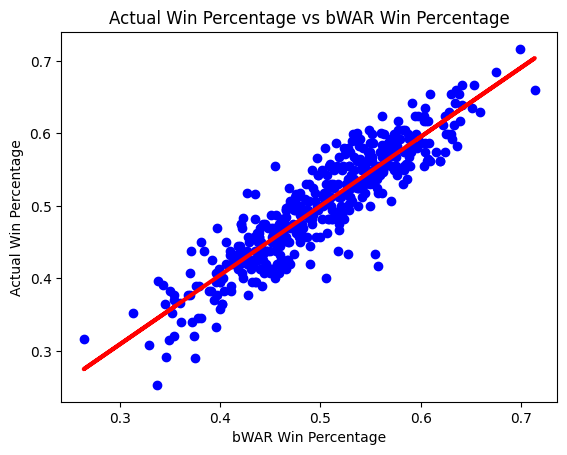

In [155]:
regr_bwar_win_pct = LinearRegression()
regr_bwar_win_pct.fit(team_records_with_war['bWAR_win_pct'].values.reshape(-1, 1), team_records_with_war['Win_Pct'].values.reshape(-1, 1))
print("Coefficients: ", regr_bwar_win_pct.coef_)
print("Intercept: ", regr_bwar_win_pct.intercept_)
print(regr_bwar_win_pct.score(team_records_with_war['bWAR_win_pct'].values.reshape(-1, 1), team_records_with_war['Win_Pct'].values.reshape(-1, 1)))
y_pred_win_pct = regr_bwar_win_pct.predict(team_records_with_war['bWAR_win_pct'].values.reshape(-1, 1))
plt.scatter(team_records_with_war['bWAR_win_pct'], team_records_with_war['Win_Pct'], color='blue', label='bWAR')
plt.plot(team_records_with_war['bWAR_win_pct'], y_pred_win_pct, color='red', linewidth=3)
plt.xlabel('bWAR Win Percentage')
plt.ylabel('Actual Win Percentage')
plt.title('Actual Win Percentage vs bWAR Win Percentage')
plt.show()

Coefficients:  [[0.90758407]]
Intercept:  [0.04619432]
0.8776272141189772


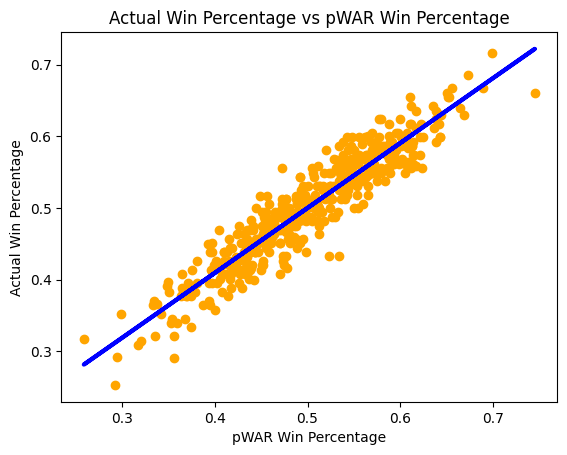

In [157]:
regr_pwar_win_pct = LinearRegression()
regr_pwar_win_pct.fit(team_records_with_war['pWAR_win_pct'].values.reshape(-1, 1), team_records_with_war['Win_Pct'].values.reshape(-1, 1))
print("Coefficients: ", regr_pwar_win_pct.coef_)
print("Intercept: ", regr_pwar_win_pct.intercept_)
print(regr_pwar_win_pct.score(team_records_with_war['pWAR_win_pct'].values.reshape(-1, 1), team_records_with_war['Win_Pct'].values.reshape(-1, 1)))
y_pred_win_pct = regr_pwar_win_pct.predict(team_records_with_war['pWAR_win_pct'].values.reshape(-1, 1))
plt.scatter(team_records_with_war['pWAR_win_pct'], team_records_with_war['Win_Pct'], color='orange', label='pWAR')
plt.plot(team_records_with_war['pWAR_win_pct'], y_pred_win_pct, color='blue', linewidth=3)
plt.xlabel('pWAR Win Percentage')
plt.ylabel('Actual Win Percentage')
plt.title('Actual Win Percentage vs pWAR Win Percentage')
plt.show()

Coefficients:  [[0.96228319]]
Intercept:  [0.01884476]
0.8239071214205499


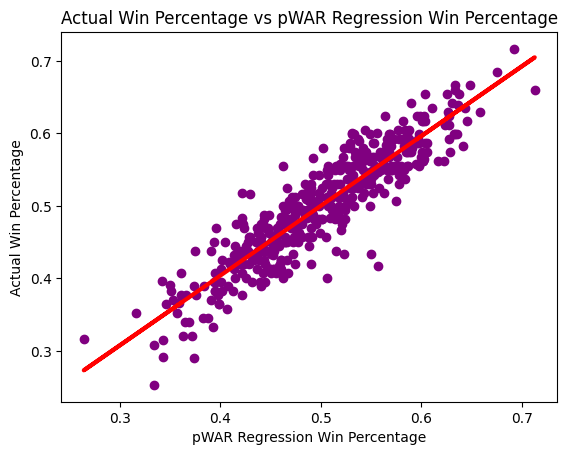

In [159]:
regr_bwar_win_pct = LinearRegression()
regr_bwar_win_pct.fit(team_records_with_war['pWAR_proj_win_pct'].values.reshape(-1, 1), team_records_with_war['Win_Pct'].values.reshape(-1, 1))
print("Coefficients: ", regr_bwar_win_pct.coef_)
print("Intercept: ", regr_bwar_win_pct.intercept_)
print(regr_bwar_win_pct.score(team_records_with_war['pWAR_proj_win_pct'].values.reshape(-1, 1), team_records_with_war['Win_Pct'].values.reshape(-1, 1)))
y_pred_win_pct = regr_bwar_win_pct.predict(team_records_with_war['pWAR_proj_win_pct'].values.reshape(-1, 1))
plt.scatter(team_records_with_war['pWAR_proj_win_pct'], team_records_with_war['Win_Pct'], color='purple', label='pWAR_proj')
plt.plot(team_records_with_war['pWAR_proj_win_pct'], y_pred_win_pct, color='red', linewidth=3)
plt.xlabel('pWAR Regression Win Percentage')
plt.ylabel('Actual Win Percentage')
plt.title('Actual Win Percentage vs pWAR Regression Win Percentage')
plt.show()

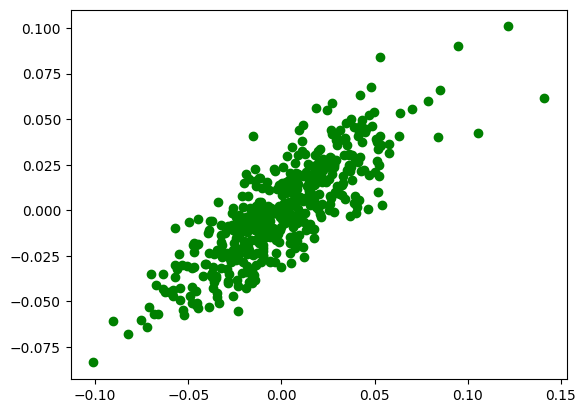

In [137]:
plt.scatter(bwar_diffs, pwar_diffs, color='green', label='Difference (bWAR vs Win_Pct)')

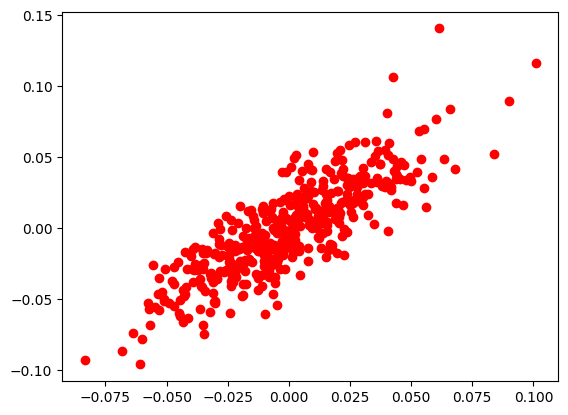

In [138]:
plt.scatter(pwar_diffs, pwar_proj_diffs, color='red', label='Difference (pWAR vs Win_Pct)')

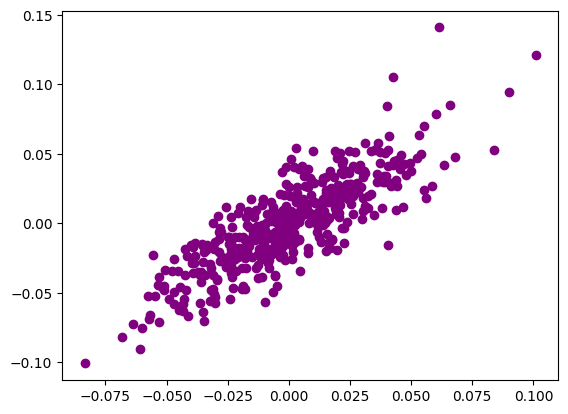

In [139]:
plt.scatter(pwar_diffs, bwar_diffs, color='purple', label='Difference (pWAR_proj vs Win_Pct)')

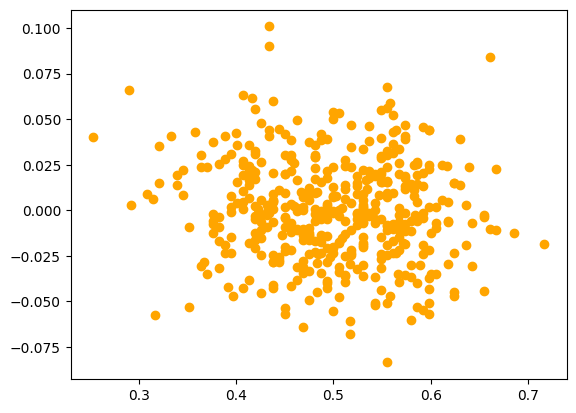

In [143]:
plt.scatter(team_records_with_war['Win_Pct'], pwar_diffs, color='orange', label='pWAR')

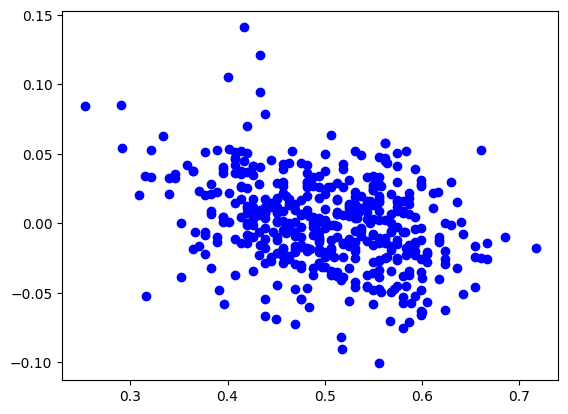

In [144]:
plt.scatter(team_records_with_war['Win_Pct'], bwar_diffs, color='blue', label='bWAR')

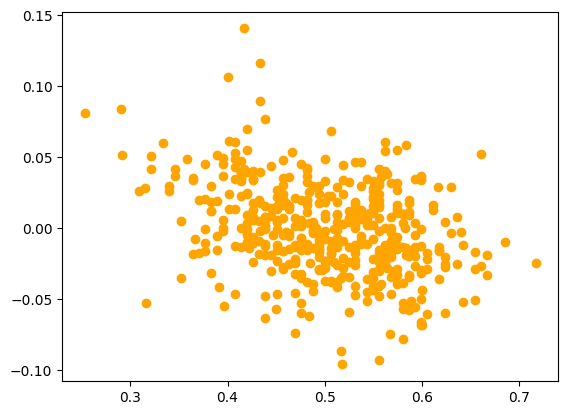

In [145]:
plt.scatter(team_records_with_war['Win_Pct'], pwar_proj_diffs, color='orange', label='pWAR_proj')

Coefficients:  [[0.00652975]]
Intercept:  [-0.00326478]
0.010929254924717524


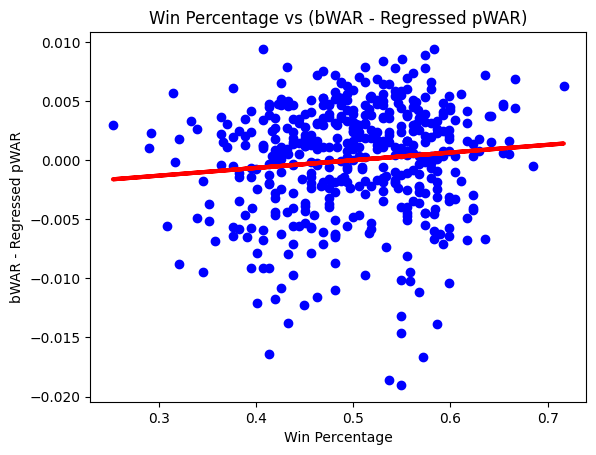

In [ ]:
regr_batter = LinearRegression()
regr_batter.fit(team_records_with_war['Win_Pct'].values.reshape(-1, 1), (bwar_diffs-pwar_proj_diffs).values.reshape(-1, 1))
print("Coefficients: ", regr_batter.coef_)
print("Intercept: ", regr_batter.intercept_)
print(regr_batter.score(team_records_with_war['Win_Pct'].values.reshape(-1, 1), (bwar_diffs-pwar_proj_diffs).values.reshape(-1, 1)))
y_pred_war_diff = regr_batter.predict(team_records_with_war['Win_Pct'].values.reshape(-1, 1))
plt.scatter(team_records_with_war['Win_Pct'], bwar_diffs - pwar_proj_diffs, color='blue')
plt.plot(team_records_with_war['Win_Pct'], y_pred_war_diff, color='red', linewidth=3)
plt.xlabel('Win Percentage')
plt.ylabel('bWAR - Regressed pWAR')
plt.title('Win Percentage vs (bWAR - Regressed pWAR)')
plt.show()

Coefficients:  [[0.10426273]]
Intercept:  [-0.05212995]
0.2021622732370093


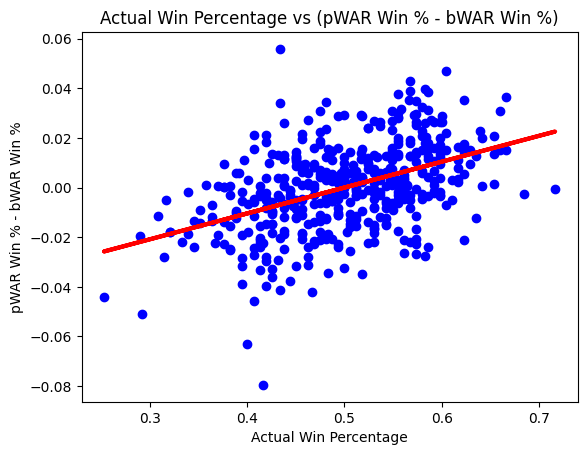

In [152]:
regr_pwar_bwar_diff = LinearRegression()
regr_pwar_bwar_diff.fit(team_records_with_war['Win_Pct'].values.reshape(-1, 1), (pwar_diffs-bwar_diffs).values.reshape(-1, 1))
print("Coefficients: ", regr_pwar_bwar_diff.coef_)
print("Intercept: ", regr_pwar_bwar_diff.intercept_)
print(regr_pwar_bwar_diff.score(team_records_with_war['Win_Pct'].values.reshape(-1, 1), (pwar_diffs-bwar_diffs).values.reshape(-1, 1)))
y_pred_war_diff = regr_pwar_bwar_diff.predict(team_records_with_war['Win_Pct'].values.reshape(-1, 1))
plt.scatter(team_records_with_war['Win_Pct'], pwar_diffs - bwar_diffs, color='blue')
plt.plot(team_records_with_war['Win_Pct'], y_pred_war_diff, color='red', linewidth=3)
plt.xlabel('Actual Win Percentage')
plt.ylabel('pWAR Win % - bWAR Win %')
plt.title('Actual Win Percentage vs (pWAR Win % - bWAR Win %)')
plt.show()